In [2]:
import cmdstanpy

try:
    path = cmdstanpy.cmdstan_path()
    print(f"CmdStan already installed at: {path}")
except ValueError:
    print("CmdStan not found. Installing now...")
    cmdstanpy.install_cmdstan()
    print(f"Installed CmdStan at: {cmdstanpy.cmdstan_path()}")

CmdStan already installed at: C:\Users\Nilotpal.Choudhury\.cmdstan\cmdstan-2.39.0


In [3]:
# Step 0: Install libraries
import subprocess
import sys

libraries = [
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "statsforecast",
    "prophet",
    "lightgbm",
    "shap",
    "plotly",
]

import_names = {
    "scikit-learn": "sklearn",
}

for lib in libraries:
    try:
        __import__(import_names.get(lib, lib))
        print(f"✓ {lib} already installed")
    except ImportError:
        print(f"Installing {lib}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", lib])
        print(f"✓ {lib} installed")

print("\nAll libraries ready!")

✓ pandas already installed
✓ numpy already installed
✓ matplotlib already installed
✓ seaborn already installed
✓ scikit-learn already installed
✓ statsforecast already installed
✓ prophet already installed
✓ lightgbm already installed
✓ shap already installed
✓ plotly already installed

All libraries ready!


# Step 1: Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from statsforecast.models import AutoARIMA, AutoETS, MSTL
from statsforecast.core import StatsForecast
from prophet import Prophet
import lightgbm as lgb
import shap
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
pd.set_option('display.max_columns', None)
print("All imports successful!")

All imports successful!


# Step 2: Load Data + Parse Dates

In [5]:
# Load dataset
df = pd.read_csv('demand_forecasting.csv')

# Parse dates
df['Date'] = pd.to_datetime(df['Date'])

# Display basic info
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")

Dataset loaded: 76000 rows, 16 columns
Date range: 2022-01-01 00:00:00 to 2024-01-30 00:00:00

Column names:
['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount', 'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality', 'Epidemic', 'Demand']

Data types:
Date                  datetime64[ns]
Store ID                      object
Product ID                    object
Category                      object
Region                        object
Inventory Level                int64
Units Sold                     int64
Units Ordered                  int64
Price                        float64
Discount                       int64
Weather Condition             object
Promotion                      int64
Competitor Pricing           float64
Seasonality                   object
Epidemic                       int64
Demand                         int64
dtype: object


# Step 3: EDA - Shape, Data Types, Nulls, Duplicates, Describe

In [6]:
print("=" * 80)
print("SHAPE")
print("=" * 80)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n" + "=" * 80)
print("DATA TYPES")
print("=" * 80)
print(df.dtypes)

print("\n" + "=" * 80)
print("MISSING VALUES")
print("=" * 80)
print(df.isnull().sum())
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
print(f"\nMissing %:\n{missing_pct[missing_pct > 0] if (missing_pct > 0).any() else 'None'}")

print("\n" + "=" * 80)
print("DUPLICATES")
print("=" * 80)
print(f"Total duplicates: {df.duplicated().sum()}")
print(f"Duplicates on [Date, Store ID, Product ID]: {df.duplicated(subset=['Date', 'Store ID', 'Product ID']).sum()}")

print("\n" + "=" * 80)
print("DESCRIPTIVE STATISTICS")
print("=" * 80)
print(df.describe())

print("\n" + "=" * 80)
print("UNIQUE VALUES")
print("=" * 80)
print(f"Unique Stores: {df['Store ID'].nunique()}")
print(f"Unique Products: {df['Product ID'].nunique()}")
print(f"Store-Product combinations: {df[['Store ID', 'Product ID']].drop_duplicates().shape[0]}")
print(f"Unique Categories: {df['Category'].nunique()}")
print(f"Unique Regions: {df['Region'].nunique()}")
print(f"Unique Weather Conditions: {df['Weather Condition'].nunique()}")
print(f"Epidemic flag values: {df['Epidemic'].unique()}")

SHAPE
Rows: 76000, Columns: 16

DATA TYPES
Date                  datetime64[ns]
Store ID                      object
Product ID                    object
Category                      object
Region                        object
Inventory Level                int64
Units Sold                     int64
Units Ordered                  int64
Price                        float64
Discount                       int64
Weather Condition             object
Promotion                      int64
Competitor Pricing           float64
Seasonality                   object
Epidemic                       int64
Demand                         int64
dtype: object

MISSING VALUES
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0

# Step 4: EDA Visualizations

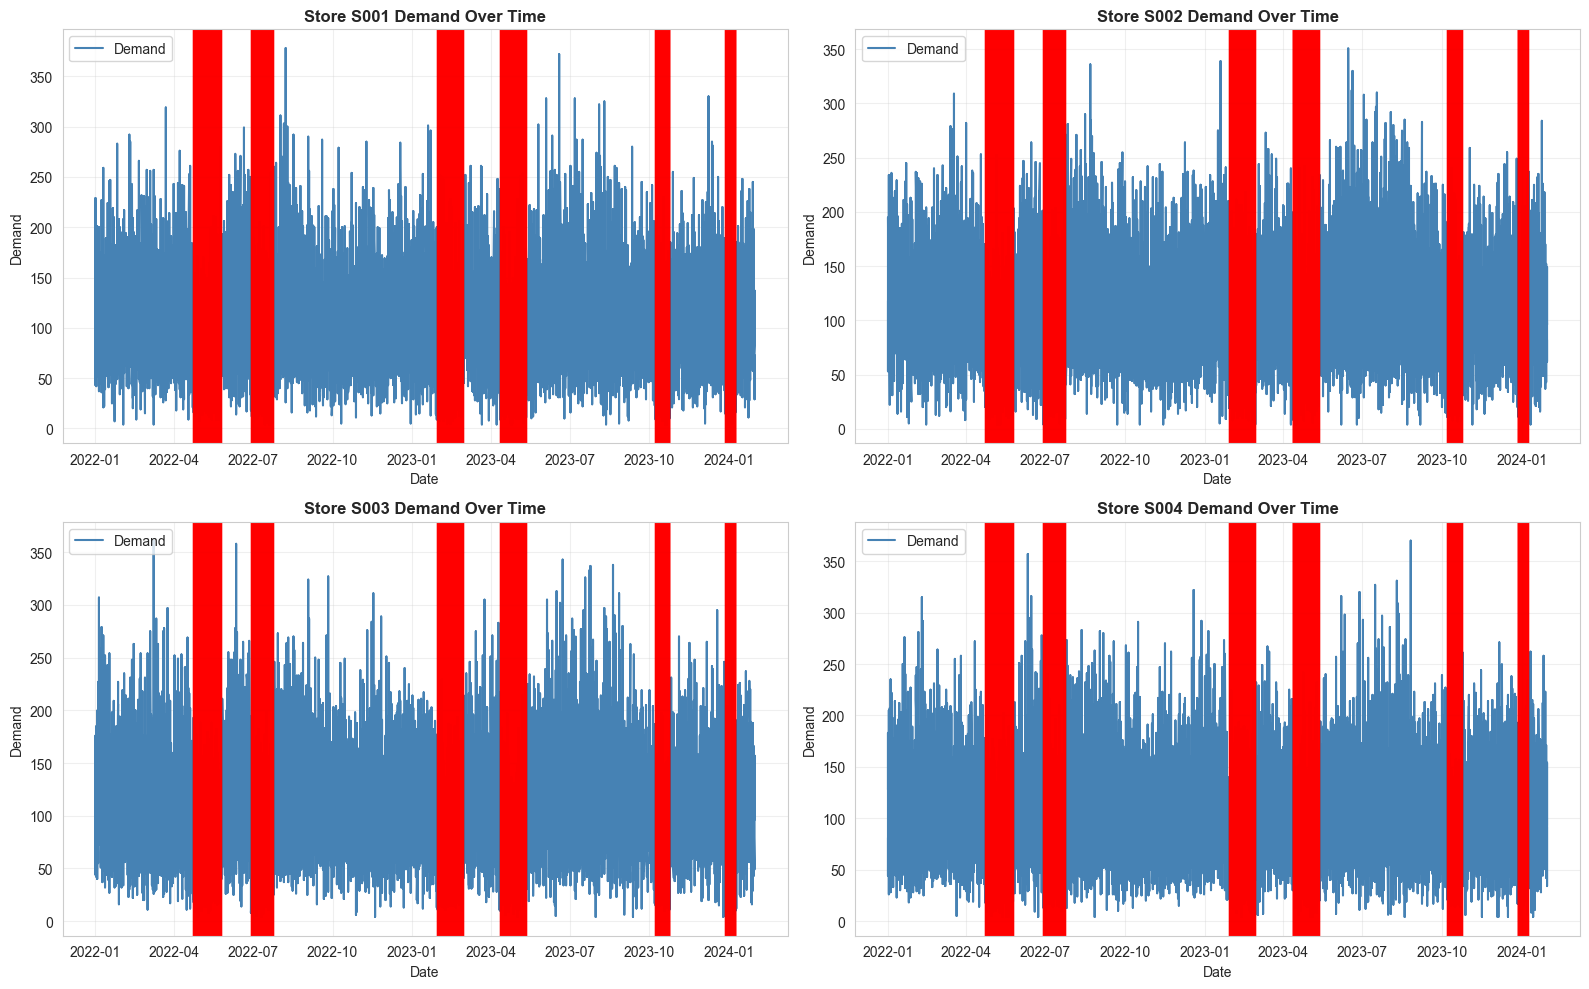

Sample time series with epidemic periods (red vertical lines) visualized.

EPIDEMIC PERIODS
Total epidemic records: 15200
Epidemic date range: 2022-04-23 00:00:00 to 2024-01-08 00:00:00
Unique epidemic dates: 152


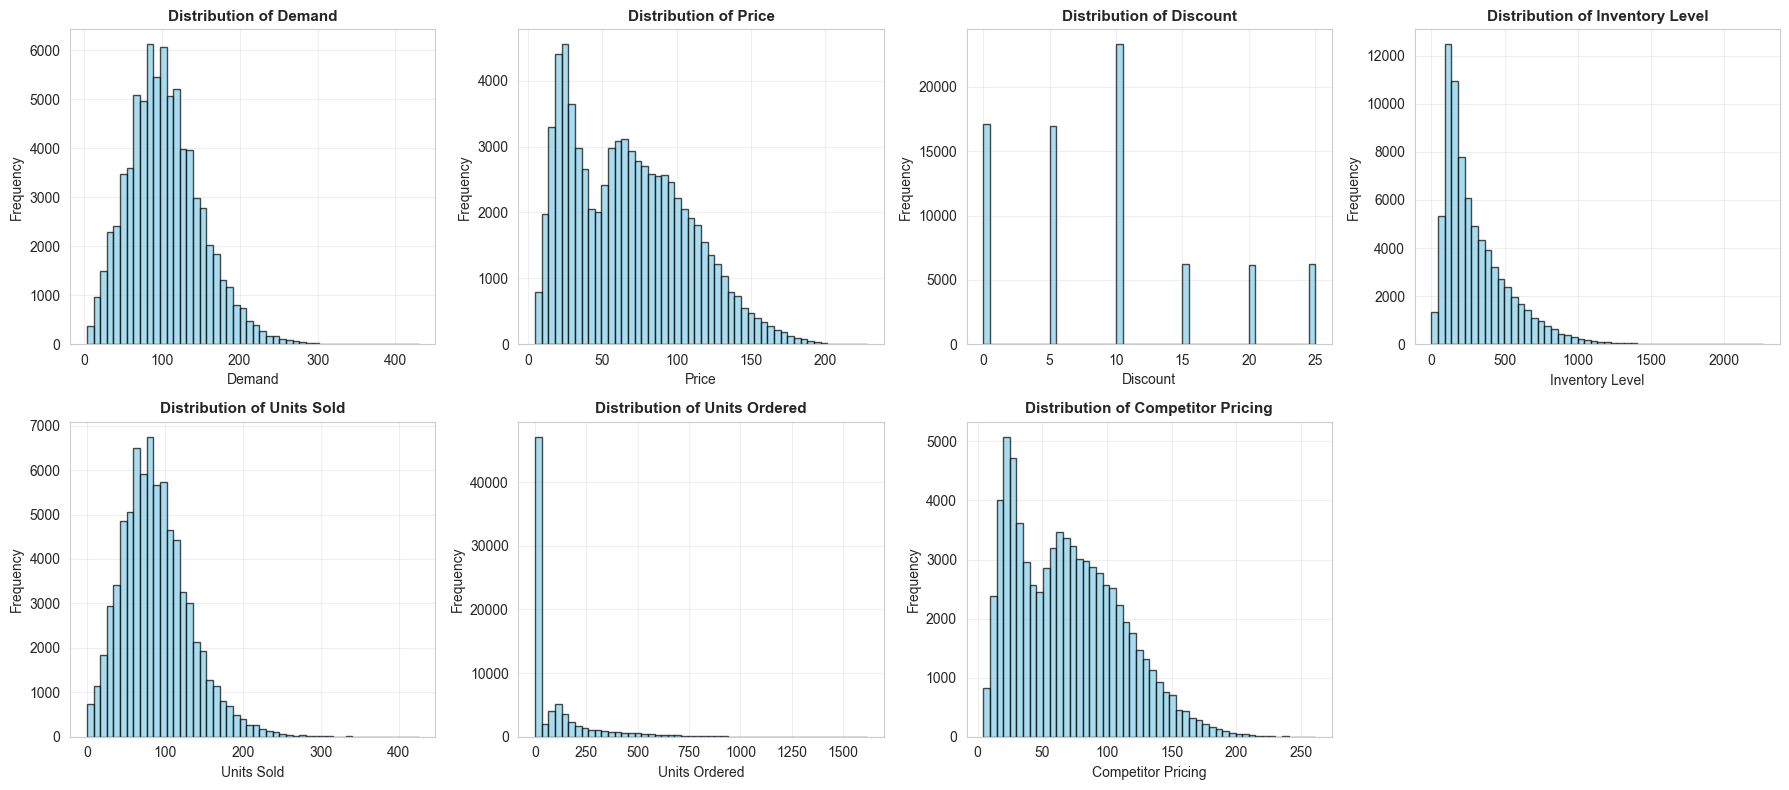


Distributions of numeric features visualized.


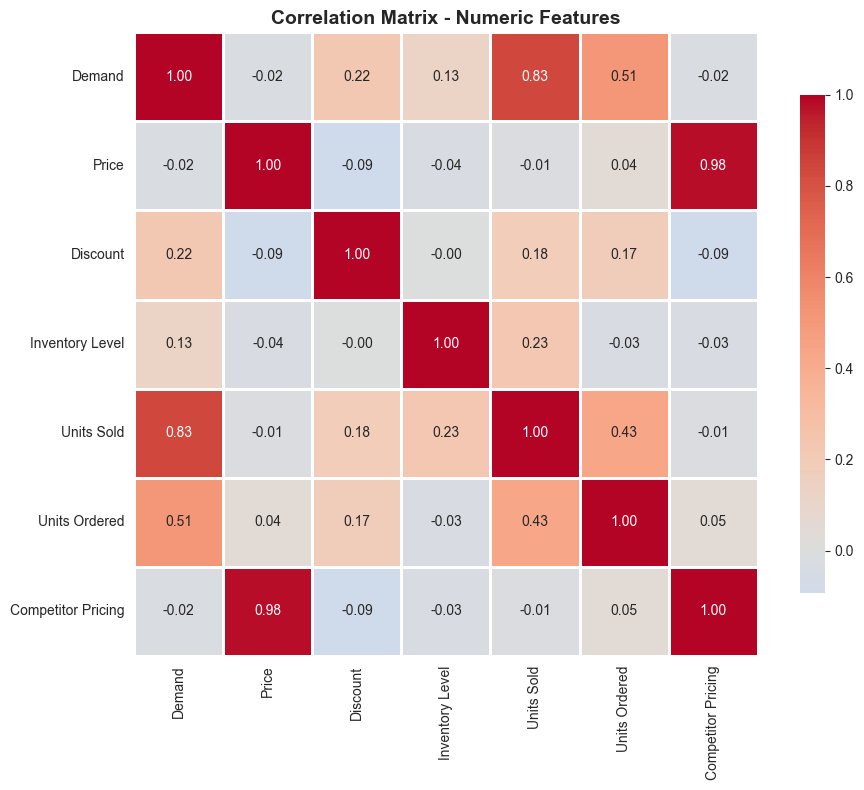

Correlation heatmap displayed.


In [7]:
# 4.1 Time Series: Sample series with epidemic periods highlighted
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for idx, (store_id, ax) in enumerate(zip(df['Store ID'].unique()[:4], axes)):
    subset = df[df['Store ID'] == store_id].sort_values('Date')
    
    ax.plot(subset['Date'], subset['Demand'], label='Demand', linewidth=1.5, color='steelblue')
    
    # Highlight epidemic periods
    epidemic_periods = subset[subset['Epidemic'] == 1]
    for _, row in epidemic_periods.iterrows():
        ax.axvline(row['Date'], color='red', alpha=0.3, linewidth=0.8)
    
    ax.set_title(f'Store {store_id} Demand Over Time', fontsize=12, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Demand')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Sample time series with epidemic periods (red vertical lines) visualized.")

# 4.2 Epidemic periods summary
print("\n" + "=" * 80)
print("EPIDEMIC PERIODS")
print("=" * 80)
epidemic_dates = df[df['Epidemic'] == 1]['Date'].sort_values()
print(f"Total epidemic records: {len(epidemic_dates)}")
print(f"Epidemic date range: {epidemic_dates.min()} to {epidemic_dates.max()}")
print(f"Unique epidemic dates: {epidemic_dates.nunique()}")

# 4.3 Distributions of numeric features
numeric_cols = ['Demand', 'Price', 'Discount', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Competitor Pricing']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(df[col], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)

# Hide last unused subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

print("\nDistributions of numeric features visualized.")

# 4.4 Correlation heatmap
correlation = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlation heatmap displayed.")

# Step 5: Feature Groups + Create unique_id

In [8]:
# Create unique_id: combination of Store ID and Product ID
df['unique_id'] = df['Store ID'].astype(str) + '_' + df['Product ID'].astype(str)

# Define feature groups
numeric_features = ['Price', 'Discount', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Competitor Pricing']
categorical_features = ['Category', 'Region', 'Weather Condition', 'Seasonality']
binary_features = ['Promotion', 'Epidemic']
time_series_id = ['Date', 'unique_id']
target = ['Demand']

print("Feature Groups Defined:")
print(f"  Numeric (StandardScaler): {numeric_features}")
print(f"  Categorical (OneHotEncoder): {categorical_features}")
print(f"  Binary (passthrough): {binary_features}")
print(f"  Time Series IDs: {time_series_id}")
print(f"  Target: {target}")

print(f"\nDataset enriched with unique_id. Total unique series: {df['unique_id'].nunique()}")
print(f"Sample unique_ids: {df['unique_id'].unique()[:5].tolist()}")

# Sort by date and unique_id for consistency
df = df.sort_values(['unique_id', 'Date']).reset_index(drop=True)
print(f"\nDataset sorted by unique_id and Date. Shape: {df.shape}")

Feature Groups Defined:
  Numeric (StandardScaler): ['Price', 'Discount', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Competitor Pricing']
  Categorical (OneHotEncoder): ['Category', 'Region', 'Weather Condition', 'Seasonality']
  Binary (passthrough): ['Promotion', 'Epidemic']
  Time Series IDs: ['Date', 'unique_id']
  Target: ['Demand']

Dataset enriched with unique_id. Total unique series: 100
Sample unique_ids: ['S001_P0001', 'S001_P0002', 'S001_P0003', 'S001_P0004', 'S001_P0005']

Dataset sorted by unique_id and Date. Shape: (76000, 17)


# Step 6: ColumnTransformer + Pipeline (fit on train, transform train + test)

In [9]:
# Define train-test split based on plan: 2024-01-16 is last train date
train_date = pd.Timestamp('2024-01-16')

df_train_split = df[df['Date'] <= train_date].copy()
df_test_split = df[df['Date'] > train_date].copy()

print(f"Train period: {df_train_split['Date'].min()} to {df_train_split['Date'].max()}")
print(f"Train rows: {len(df_train_split)}")
print(f"Test period: {df_test_split['Date'].min()} to {df_test_split['Date'].max()}")
print(f"Test rows: {len(df_test_split)}")

# ColumnTransformer: fit on training data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features),
        ('bin', 'passthrough', binary_features)
    ],
    remainder='drop'
)

print("\n" + "=" * 80)
print("FITTING PREPROCESSOR ON TRAINING DATA")
print("=" * 80)

# Fit on training data
X_train_processed = preprocessor.fit_transform(df_train_split[numeric_features + categorical_features + binary_features])
print(f"Training features shape after preprocessing: {X_train_processed.shape}")

# Transform test data using the fitted preprocessor
X_test_processed = preprocessor.transform(df_test_split[numeric_features + categorical_features + binary_features])
print(f"Test features shape after preprocessing: {X_test_processed.shape}")

# Get feature names for later use (optional)
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names) + binary_features
print(f"\nTotal features after preprocessing: {len(all_feature_names)}")
print(f"Feature names sample: {all_feature_names[:10]}")

# Store preprocessed data with metadata
df_train_processed = df_train_split.copy()
df_train_processed['_processed_features'] = [X_train_processed[i] for i in range(len(X_train_processed))]

df_test_processed = df_test_split.copy()
df_test_processed['_processed_features'] = [X_test_processed[i] for i in range(len(X_test_processed))]

print("\nPreprocessor fitted and training/test data transformed successfully!")

Train period: 2022-01-01 00:00:00 to 2024-01-16 00:00:00
Train rows: 74600
Test period: 2024-01-17 00:00:00 to 2024-01-30 00:00:00
Test rows: 1400

FITTING PREPROCESSOR ON TRAINING DATA
Training features shape after preprocessing: (74600, 21)
Test features shape after preprocessing: (1400, 21)

Total features after preprocessing: 21
Feature names sample: ['Price', 'Discount', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Competitor Pricing', 'Category_Electronics', 'Category_Furniture', 'Category_Groceries', 'Category_Toys']

Preprocessor fitted and training/test data transformed successfully!


# Step 7: Train/Test Split + Build StatsForecast DataFrames

In [10]:
print("=" * 80)
print("PREPARING STATSFORECAST DATAFRAMES (WITH EXOGENOUS FEATURES)")
print("=" * 80)

# Core data in StatsForecast format
core_train = df_train_split[['Date', 'Demand', 'unique_id']].copy()
core_test = df_test_split[['Date', 'Demand', 'unique_id']].copy()

core_train.columns = ['ds', 'y', 'unique_id']
core_test.columns = ['ds', 'y', 'unique_id']

# Build tabular exogenous feature frames from preprocessed arrays
X_train_df = pd.DataFrame(X_train_processed, columns=all_feature_names, index=df_train_split.index)
X_test_df = pd.DataFrame(X_test_processed, columns=all_feature_names, index=df_test_split.index)

# Train dataframe (includes y + exogenous vars)
statsforecast_train_exog = pd.concat(
    [core_train.reset_index(drop=True), X_train_df.reset_index(drop=True)],
    axis=1
).sort_values(['unique_id', 'ds']).reset_index(drop=True)

# Future exogenous dataframe for forecast horizon (NO y)
statsforecast_future_exog = pd.concat(
    [core_test[['ds', 'unique_id']].reset_index(drop=True), X_test_df.reset_index(drop=True)],
    axis=1
).sort_values(['unique_id', 'ds']).reset_index(drop=True)

# Test actuals for evaluation
statsforecast_test_actual = core_test.sort_values(['unique_id', 'ds']).reset_index(drop=True)

# Keep baseline no-exog train frame for models that do not use regressors
statsforecast_train_base = core_train.sort_values(['unique_id', 'ds']).reset_index(drop=True)

print(f"StatsForecast Training (with exog) shape: {statsforecast_train_exog.shape}")
print(f"StatsForecast Future exog shape: {statsforecast_future_exog.shape}")
print(f"StatsForecast Test actual shape: {statsforecast_test_actual.shape}")
print(f"Exogenous feature count: {len(all_feature_names)}")

print(f"\nTraining set:")
print(f"  Unique series: {statsforecast_train_exog['unique_id'].nunique()}")
print(f"  Date range: {statsforecast_train_exog['ds'].min()} to {statsforecast_train_exog['ds'].max()}")
print(f"  Sample cols: {statsforecast_train_exog.columns[:8].tolist()}")

print(f"\nFuture exogenous set:")
print(f"  Unique series: {statsforecast_future_exog['unique_id'].nunique()}")
print(f"  Date range: {statsforecast_future_exog['ds'].min()} to {statsforecast_future_exog['ds'].max()}")
print(f"  Sample cols: {statsforecast_future_exog.columns[:8].tolist()}")

# Define forecast horizon (14 days as per plan)
h = 14
print(f"\nForecast horizon: {h} days")
print(f"Expected predictions: {statsforecast_test_actual['unique_id'].nunique()} series x {h} steps")

# Verify test set covers exactly h days per series
test_days_per_series = statsforecast_test_actual.groupby('unique_id')['ds'].count()
print(f"\nDays per series in test set:")
print(f"  Min: {test_days_per_series.min()}, Max: {test_days_per_series.max()}, Expected: {h}")

if (test_days_per_series == h).all():
    print("OK: Test set correctly structured: each series has exactly h days")
else:
    print("WARNING: Some series do not have exactly h days")

print("\nStatsForecast dataframes ready for modeling with exogenous features!")

PREPARING STATSFORECAST DATAFRAMES (WITH EXOGENOUS FEATURES)
StatsForecast Training (with exog) shape: (74600, 24)
StatsForecast Future exog shape: (1400, 23)
StatsForecast Test actual shape: (1400, 3)
Exogenous feature count: 21

Training set:
  Unique series: 100
  Date range: 2022-01-01 00:00:00 to 2024-01-16 00:00:00
  Sample cols: ['ds', 'y', 'unique_id', 'Price', 'Discount', 'Inventory Level', 'Units Sold', 'Units Ordered']

Future exogenous set:
  Unique series: 100
  Date range: 2024-01-17 00:00:00 to 2024-01-30 00:00:00
  Sample cols: ['ds', 'unique_id', 'Price', 'Discount', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Competitor Pricing']

Forecast horizon: 14 days
Expected predictions: 100 series x 14 steps

Days per series in test set:
  Min: 14, Max: 14, Expected: 14
OK: Test set correctly structured: each series has exactly h days

StatsForecast dataframes ready for modeling with exogenous features!


# Step 8: StatsForecast Modeling (with and without exogenous variables)

In [11]:
print("=" * 80)
print("RUNNING STATSFORECAST MODELS")
print("=" * 80)

# Model 1: AutoARIMA with exogenous regressors
sf_arima_exog = StatsForecast(
    models=[AutoARIMA(season_length=7)],
    freq='D',
    n_jobs=-1
)

sf_arima_exog.fit(statsforecast_train_exog)
pred_arima_exog = sf_arima_exog.predict(h=h, X_df=statsforecast_future_exog)
pred_arima_exog = pred_arima_exog.sort_values(['unique_id', 'ds']).reset_index(drop=True)

print("AutoARIMA (with exogenous features) complete")
print(f"Prediction shape: {pred_arima_exog.shape}")
print(pred_arima_exog.head())

# Models 2-3: Baselines without exogenous regressors
sf_baseline = StatsForecast(
    models=[
        AutoETS(season_length=7),
        MSTL(season_length=[7, 30])
    ],
    freq='D',
    n_jobs=-1
)

sf_baseline.fit(statsforecast_train_base)
pred_baseline = sf_baseline.predict(h=h)
pred_baseline = pred_baseline.sort_values(['unique_id', 'ds']).reset_index(drop=True)

print("\nAutoETS + MSTL (baseline, no exogenous features) complete")
print(f"Prediction shape: {pred_baseline.shape}")
print(pred_baseline.head())

# Consolidated prediction frame for downstream evaluation
statsforecast_predictions = pred_baseline.merge(
    pred_arima_exog[['unique_id', 'ds', 'AutoARIMA']],
    on=['unique_id', 'ds'],
    how='left',
    suffixes=('', '_exog')
)

print("\nCombined prediction frame ready")
print(f"Shape: {statsforecast_predictions.shape}")
print(f"Columns: {statsforecast_predictions.columns.tolist()}")

RUNNING STATSFORECAST MODELS
AutoARIMA (with exogenous features) complete
Prediction shape: (1400, 3)
    unique_id         ds   AutoARIMA
0  S001_P0001 2024-01-17   91.313770
1  S001_P0001 2024-01-18   87.124292
2  S001_P0001 2024-01-19   95.064941
3  S001_P0001 2024-01-20  145.732186
4  S001_P0001 2024-01-21  107.241317

AutoETS + MSTL (baseline, no exogenous features) complete
Prediction shape: (1400, 4)
    unique_id         ds    AutoETS        MSTL
0  S001_P0001 2024-01-17  78.667168   75.550507
1  S001_P0001 2024-01-18  78.667168  113.217735
2  S001_P0001 2024-01-19  78.667168   90.951202
3  S001_P0001 2024-01-20  78.667168   82.965630
4  S001_P0001 2024-01-21  78.667168   88.293610

Combined prediction frame ready
Shape: (1400, 5)
Columns: ['unique_id', 'ds', 'AutoETS', 'MSTL', 'AutoARIMA']


# Step 9: Prophet Modeling (loop 100 series with holidays + regressors)

In [12]:
print("=" * 80)
print("RUNNING PROPHET MODELS")
print("=" * 80)

# Build aligned train/test frames with processed exogenous features
prophet_train_full = pd.concat(
    [df_train_split[['Date', 'Demand', 'unique_id']].reset_index(drop=True), X_train_df.reset_index(drop=True)],
    axis=1
)
prophet_test_full = pd.concat(
    [df_test_split[['Date', 'Demand', 'unique_id']].reset_index(drop=True), X_test_df.reset_index(drop=True)],
    axis=1
)

# Create holidays dataframe from all epidemic dates (both periods)
epidemic_holidays = df.loc[df['Epidemic'] == 1, ['Date']].drop_duplicates().copy()
epidemic_holidays = epidemic_holidays.rename(columns={'Date': 'ds'})
epidemic_holidays['holiday'] = 'epidemic'

all_series = sorted(prophet_train_full['unique_id'].unique())
prophet_forecasts = []
prophet_failures = []

print(f"Total series to fit: {len(all_series)}")
print(f"Holiday dates passed to Prophet: {len(epidemic_holidays)}")

for i, uid in enumerate(all_series, start=1):
    train_s = prophet_train_full[prophet_train_full['unique_id'] == uid].copy()
    test_s = prophet_test_full[prophet_test_full['unique_id'] == uid].copy()

    train_s = train_s.sort_values('Date').reset_index(drop=True)
    test_s = test_s.sort_values('Date').reset_index(drop=True)

    # Prophet expects ds/y column names
    prophet_train = train_s.rename(columns={'Date': 'ds', 'Demand': 'y'})
    future = test_s.rename(columns={'Date': 'ds'}).copy()

    # Only use non-constant regressors for this series
    candidate_regressors = [c for c in all_feature_names if c in prophet_train.columns]
    valid_regressors = [c for c in candidate_regressors if prophet_train[c].nunique(dropna=False) > 1]

    try:
        m = Prophet(
            holidays=epidemic_holidays,
            daily_seasonality=False,
            weekly_seasonality=True,
            yearly_seasonality=True
        )

        for reg in valid_regressors:
            m.add_regressor(reg)

        fit_cols = ['ds', 'y'] + valid_regressors
        pred_cols = ['ds'] + valid_regressors

        m.fit(prophet_train[fit_cols])
        fcst = m.predict(future[pred_cols])[['ds', 'yhat']]
        fcst['unique_id'] = uid
        fcst['n_regressors'] = len(valid_regressors)
        prophet_forecasts.append(fcst)

    except Exception as e:
        # Fallback: Prophet without regressors so one bad series doesn't stop the run
        try:
            m = Prophet(
                holidays=epidemic_holidays,
                daily_seasonality=False,
                weekly_seasonality=True,
                yearly_seasonality=True
            )
            m.fit(prophet_train[['ds', 'y']])
            fcst = m.predict(future[['ds']])[['ds', 'yhat']]
            fcst['unique_id'] = uid
            fcst['n_regressors'] = 0
            prophet_forecasts.append(fcst)
            prophet_failures.append((uid, f"Regressor mode failed; fallback used: {str(e)[:120]}"))
        except Exception as e2:
            prophet_failures.append((uid, f"Full Prophet failure: {str(e2)[:160]}"))

    if i % 20 == 0 or i == len(all_series):
        print(f"Processed {i}/{len(all_series)} series")

pred_prophet = pd.concat(prophet_forecasts, ignore_index=True)
pred_prophet = pred_prophet.rename(columns={'yhat': 'Prophet'})
pred_prophet = pred_prophet[['unique_id', 'ds', 'Prophet', 'n_regressors']].sort_values(['unique_id', 'ds']).reset_index(drop=True)

print("\nProphet modeling complete")
print(f"Forecast rows: {len(pred_prophet)}")
print(f"Expected rows: {len(all_series) * h}")
print(f"Series with issues/fallbacks: {len(prophet_failures)}")
print(pred_prophet.head())

if prophet_failures:
    print("\nSample failures/fallbacks (up to 5):")
    for item in prophet_failures[:5]:
        print(item)

RUNNING PROPHET MODELS
Total series to fit: 100
Holiday dates passed to Prophet: 152


11:49:02 - cmdstanpy - INFO - Chain [1] start processing
11:49:03 - cmdstanpy - INFO - Chain [1] done processing
11:49:03 - cmdstanpy - INFO - Chain [1] start processing
11:49:04 - cmdstanpy - INFO - Chain [1] done processing
11:49:04 - cmdstanpy - INFO - Chain [1] start processing
11:49:04 - cmdstanpy - INFO - Chain [1] done processing
11:49:05 - cmdstanpy - INFO - Chain [1] start processing
11:49:05 - cmdstanpy - INFO - Chain [1] done processing
11:49:06 - cmdstanpy - INFO - Chain [1] start processing
11:49:06 - cmdstanpy - INFO - Chain [1] done processing
11:49:06 - cmdstanpy - INFO - Chain [1] start processing
11:49:07 - cmdstanpy - INFO - Chain [1] done processing
11:49:07 - cmdstanpy - INFO - Chain [1] start processing
11:49:08 - cmdstanpy - INFO - Chain [1] done processing
11:49:08 - cmdstanpy - INFO - Chain [1] start processing
11:49:09 - cmdstanpy - INFO - Chain [1] done processing
11:49:09 - cmdstanpy - INFO - Chain [1] start processing
11:49:10 - cmdstanpy - INFO - Chain [1]

Processed 20/100 series


11:49:20 - cmdstanpy - INFO - Chain [1] start processing
11:49:20 - cmdstanpy - INFO - Chain [1] done processing
11:49:21 - cmdstanpy - INFO - Chain [1] start processing
11:49:21 - cmdstanpy - INFO - Chain [1] done processing
11:49:22 - cmdstanpy - INFO - Chain [1] start processing
11:49:22 - cmdstanpy - INFO - Chain [1] done processing
11:49:22 - cmdstanpy - INFO - Chain [1] start processing
11:49:23 - cmdstanpy - INFO - Chain [1] done processing
11:49:23 - cmdstanpy - INFO - Chain [1] start processing
11:49:24 - cmdstanpy - INFO - Chain [1] done processing
11:49:24 - cmdstanpy - INFO - Chain [1] start processing
11:49:24 - cmdstanpy - INFO - Chain [1] done processing
11:49:25 - cmdstanpy - INFO - Chain [1] start processing
11:49:25 - cmdstanpy - INFO - Chain [1] done processing
11:49:26 - cmdstanpy - INFO - Chain [1] start processing
11:49:26 - cmdstanpy - INFO - Chain [1] done processing
11:49:27 - cmdstanpy - INFO - Chain [1] start processing
11:49:27 - cmdstanpy - INFO - Chain [1]

Processed 40/100 series


...

Processed 60/100 series


11:49:54 - cmdstanpy - INFO - Chain [1] start processing
11:49:55 - cmdstanpy - INFO - Chain [1] done processing
11:49:55 - cmdstanpy - INFO - Chain [1] start processing
11:49:56 - cmdstanpy - INFO - Chain [1] done processing
11:49:56 - cmdstanpy - INFO - Chain [1] start processing
11:49:57 - cmdstanpy - INFO - Chain [1] done processing
11:49:57 - cmdstanpy - INFO - Chain [1] start processing
11:49:57 - cmdstanpy - INFO - Chain [1] done processing
11:49:58 - cmdstanpy - INFO - Chain [1] start processing
11:49:58 - cmdstanpy - INFO - Chain [1] done processing
11:49:59 - cmdstanpy - INFO - Chain [1] start processing
11:49:59 - cmdstanpy - INFO - Chain [1] done processing
11:50:00 - cmdstanpy - INFO - Chain [1] start processing
11:50:00 - cmdstanpy - INFO - Chain [1] done processing
11:50:01 - cmdstanpy - INFO - Chain [1] start processing
11:50:01 - cmdstanpy - INFO - Chain [1] done processing
11:50:01 - cmdstanpy - INFO - Chain [1] start processing
11:50:02 - cmdstanpy - INFO - Chain [1]

Processed 80/100 series


11:50:13 - cmdstanpy - INFO - Chain [1] start processing
11:50:13 - cmdstanpy - INFO - Chain [1] done processing
11:50:14 - cmdstanpy - INFO - Chain [1] start processing
11:50:14 - cmdstanpy - INFO - Chain [1] done processing
11:50:15 - cmdstanpy - INFO - Chain [1] start processing
11:50:15 - cmdstanpy - INFO - Chain [1] done processing
11:50:15 - cmdstanpy - INFO - Chain [1] start processing
11:50:16 - cmdstanpy - INFO - Chain [1] done processing
11:50:17 - cmdstanpy - INFO - Chain [1] start processing
11:50:17 - cmdstanpy - INFO - Chain [1] done processing
11:50:17 - cmdstanpy - INFO - Chain [1] start processing
11:50:18 - cmdstanpy - INFO - Chain [1] done processing
11:50:18 - cmdstanpy - INFO - Chain [1] start processing
11:50:19 - cmdstanpy - INFO - Chain [1] done processing
11:50:19 - cmdstanpy - INFO - Chain [1] start processing
11:50:20 - cmdstanpy - INFO - Chain [1] done processing
11:50:20 - cmdstanpy - INFO - Chain [1] start processing
11:50:21 - cmdstanpy - INFO - Chain [1]

Processed 100/100 series

Prophet modeling complete
Forecast rows: 1400
Expected rows: 1400
Series with issues/fallbacks: 0
    unique_id         ds     Prophet  n_regressors
0  S001_P0001 2024-01-17   91.212221            14
1  S001_P0001 2024-01-18   86.635804            14
2  S001_P0001 2024-01-19   95.093019            14
3  S001_P0001 2024-01-20  145.682415            14
4  S001_P0001 2024-01-21  106.998104            14


# Step 10: Evaluate MAPE, RMSE, MAE (all 4 models)

In [13]:
print("=" * 80)
print("EVALUATING FORECAST ACCURACY")
print("=" * 80)

# Join actuals and predictions
eval_df = statsforecast_test_actual.copy().rename(columns={'y': 'actual'})
eval_df = eval_df.merge(statsforecast_predictions, on=['unique_id', 'ds'], how='left')
eval_df = eval_df.merge(pred_prophet[['unique_id', 'ds', 'Prophet']], on=['unique_id', 'ds'], how='left')

model_cols = ['AutoARIMA', 'AutoETS', 'MSTL', 'Prophet']

def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    denom = np.where(np.abs(y_true) < 1e-8, np.nan, y_true)
    mape = np.nanmean(np.abs((y_true - y_pred) / denom)) * 100
    return mae, rmse, mape

# Overall metrics
rows = []
for m in model_cols:
    tmp = eval_df[['actual', m]].dropna()
    mae, rmse, mape = compute_metrics(tmp['actual'], tmp[m])
    rows.append({'Model': m, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'N': len(tmp)})

metrics_table = pd.DataFrame(rows).sort_values('RMSE').reset_index(drop=True)
print("Overall metrics across all 100 series and 14 days:")
print(metrics_table)

# Best model by metric
best_mae = metrics_table.loc[metrics_table['MAE'].idxmin(), 'Model']
best_rmse = metrics_table.loc[metrics_table['RMSE'].idxmin(), 'Model']
best_mape = metrics_table.loc[metrics_table['MAPE'].idxmin(), 'Model']

print("\nBest models:")
print(f"  MAE  -> {best_mae}")
print(f"  RMSE -> {best_rmse}")
print(f"  MAPE -> {best_mape}")

# Per-series RMSE diagnostic (average by model)
series_rows = []
for uid, g in eval_df.groupby('unique_id'):
    for m in model_cols:
        tmp = g[['actual', m]].dropna()
        if len(tmp) == 0:
            continue
        mae, rmse, mape = compute_metrics(tmp['actual'], tmp[m])
        series_rows.append({'unique_id': uid, 'Model': m, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape})

series_metrics = pd.DataFrame(series_rows)
series_summary = series_metrics.groupby('Model')[['MAE', 'RMSE', 'MAPE']].mean().sort_values('RMSE').reset_index()

print("\nMean per-series metrics (each series weighted equally):")
print(series_summary)

# Keep objects for downstream steps
forecast_eval_df = eval_df
overall_metrics = metrics_table
per_series_metrics = series_metrics
print("\nEvaluation artifacts saved: forecast_eval_df, overall_metrics, per_series_metrics")

EVALUATING FORECAST ACCURACY
Overall metrics across all 100 series and 14 days:
       Model        MAE       RMSE       MAPE     N
0  AutoARIMA   3.533102   4.615029   3.933164  1400
1    Prophet   3.613415   4.721440   4.009995  1400
2    AutoETS  32.153726  41.752021  36.890487  1400
3       MSTL  35.637727  45.894227  40.704037  1400

Best models:
  MAE  -> AutoARIMA
  RMSE -> AutoARIMA
  MAPE -> AutoARIMA

Mean per-series metrics (each series weighted equally):
       Model        MAE       RMSE       MAPE
0  AutoARIMA   3.533102   4.483458   3.933164
1    Prophet   3.613415   4.599787   4.009995
2    AutoETS  32.153726  40.420851  36.890487
3       MSTL  35.637727  44.405448  40.704037

Evaluation artifacts saved: forecast_eval_df, overall_metrics, per_series_metrics


# Step 11: Forecast Visualisation (sample series with model overlays)

STEP 11: FORECAST VISUALISATION
Selected sample series (6): ['S001_P0002', 'S001_P0001', 'S001_P0010', 'S001_P0005', 'S001_P0006', 'S001_P0003']


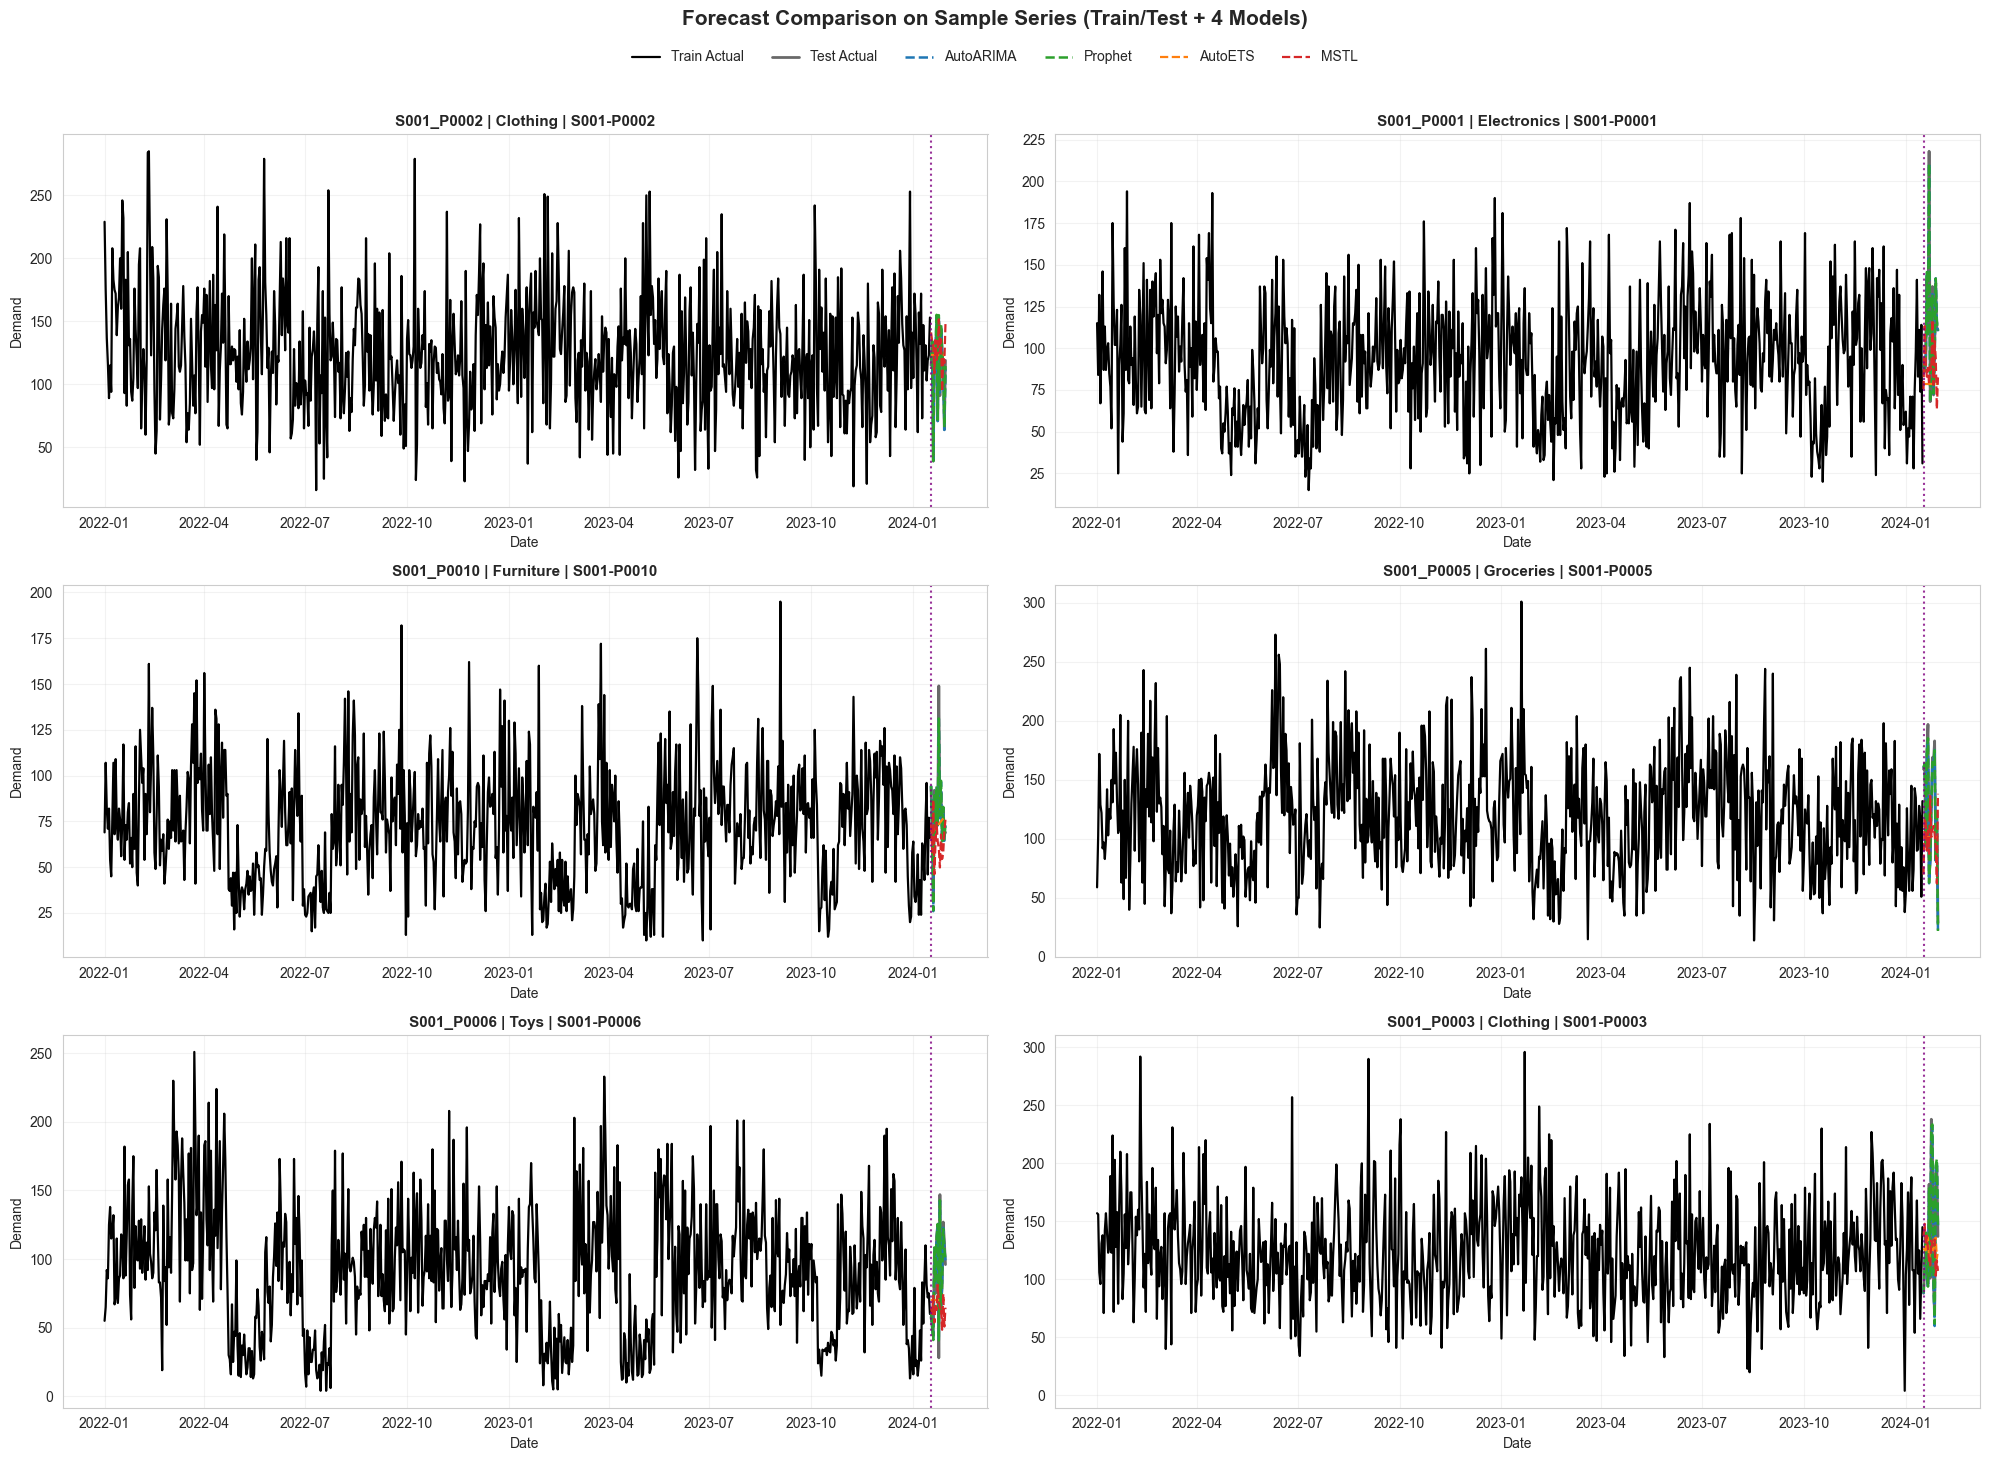


Sample forecast snapshot (first 12 rows):
     unique_id         ds  actual   AutoARIMA    AutoETS        MSTL  \
0   S001_P0001 2024-01-17      88   91.313770  78.667168   75.550507   
1   S001_P0001 2024-01-18      86   87.124292  78.667168  113.217735   
2   S001_P0001 2024-01-19      90   95.064941  78.667168   90.951202   
3   S001_P0001 2024-01-20     141  145.732186  78.667168   82.965630   
4   S001_P0001 2024-01-21     109  107.241317  78.667168   88.293610   
5   S001_P0001 2024-01-22     218  210.939329  78.667168   78.125526   
6   S001_P0001 2024-01-23      68   67.803125  78.667168   89.235291   
7   S001_P0001 2024-01-24      98   99.544500  78.667168   87.338051   
8   S001_P0001 2024-01-25     137  132.378839  78.667168  116.958817   
9   S001_P0001 2024-01-26      72   72.629727  78.667168   78.022926   
10  S001_P0001 2024-01-27      99   94.986044  78.667168  104.327324   
11  S001_P0001 2024-01-28     139  141.900931  78.667168   94.183037   

       Prophet  
0  

In [14]:
print("=" * 80)
print("STEP 11: FORECAST VISUALISATION")
print("=" * 80)

# Build a compact metadata table for series selection
series_meta = (
    df[['unique_id', 'Category', 'Store ID', 'Product ID']]
    .drop_duplicates(subset=['unique_id'])
    .sort_values(['Category', 'Store ID', 'Product ID'])
    .reset_index(drop=True)
)

# Select up to 6 representative series: one per category first, then fill remaining slots
sample_series_ids = []
for cat in sorted(series_meta['Category'].unique()):
    first_uid = series_meta.loc[series_meta['Category'] == cat, 'unique_id'].iloc[0]
    sample_series_ids.append(first_uid)

if len(sample_series_ids) < 6:
    remaining = [uid for uid in series_meta['unique_id'].tolist() if uid not in sample_series_ids]
    sample_series_ids.extend(remaining[: (6 - len(sample_series_ids))])

sample_series_ids = sample_series_ids[:6]

# Assemble test prediction frame for plotting
plot_test = forecast_eval_df.copy()
plot_test = plot_test[['unique_id', 'ds', 'actual', 'AutoARIMA', 'AutoETS', 'MSTL', 'Prophet']]

# Train actuals for context
plot_train = (
    df_train_split[['unique_id', 'Date', 'Demand']]
    .rename(columns={'Date': 'ds', 'Demand': 'actual_train'})
    .sort_values(['unique_id', 'ds'])
)

print(f"Selected sample series ({len(sample_series_ids)}): {sample_series_ids}")

fig, axes = plt.subplots(3, 2, figsize=(20, 14), sharex=False)
axes = axes.ravel()

for idx, uid in enumerate(sample_series_ids):
    ax = axes[idx]

    train_s = plot_train[plot_train['unique_id'] == uid]
    test_s = plot_test[plot_test['unique_id'] == uid]

    # Actuals
    ax.plot(train_s['ds'], train_s['actual_train'], color='black', linewidth=1.6, label='Train Actual')
    ax.plot(test_s['ds'], test_s['actual'], color='dimgray', linewidth=2.0, label='Test Actual')

    # Model forecasts
    ax.plot(test_s['ds'], test_s['AutoARIMA'], color='tab:blue', linestyle='--', linewidth=1.8, label='AutoARIMA')
    ax.plot(test_s['ds'], test_s['Prophet'], color='tab:green', linestyle='--', linewidth=1.8, label='Prophet')
    ax.plot(test_s['ds'], test_s['AutoETS'], color='tab:orange', linestyle='--', linewidth=1.6, label='AutoETS')
    ax.plot(test_s['ds'], test_s['MSTL'], color='tab:red', linestyle='--', linewidth=1.6, label='MSTL')

    # Vertical split marker at train/test boundary
    split_date = test_s['ds'].min()
    ax.axvline(split_date, color='purple', linestyle=':', linewidth=1.5, alpha=0.8)

    cat = series_meta.loc[series_meta['unique_id'] == uid, 'Category'].iloc[0]
    store = series_meta.loc[series_meta['unique_id'] == uid, 'Store ID'].iloc[0]
    prod = series_meta.loc[series_meta['unique_id'] == uid, 'Product ID'].iloc[0]
    ax.set_title(f"{uid} | {cat} | {store}-{prod}", fontsize=11, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Demand')
    ax.grid(True, alpha=0.25)

# If fewer than 6 chosen, hide empty axes
for j in range(len(sample_series_ids), len(axes)):
    axes[j].axis('off')

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=6, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle('Forecast Comparison on Sample Series (Train/Test + 4 Models)', fontsize=15, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

# Optional: quick tabular snapshot for selected series over test horizon
sample_snapshot = plot_test[plot_test['unique_id'].isin(sample_series_ids)].copy()
print("\nSample forecast snapshot (first 12 rows):")
print(sample_snapshot.head(12))

# Step 12: Feature Importance (LightGBM surrogate + SHAP)

STEP 12: FEATURE IMPORTANCE WITH LIGHTGBM + SHAP
Surrogate feature matrix shape: (74600, 26)
Target shape: (74600,)
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004543 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1389
[LightGBM] [Info] Number of data points in the train set: 59680, number of used features: 26
[LightGBM] [Info] Start training from score 104.391806

Surrogate LightGBM validation metrics:
  MAE: 10.0900
  RMSE: 13.2701

Computing SHAP values on 5000 rows...


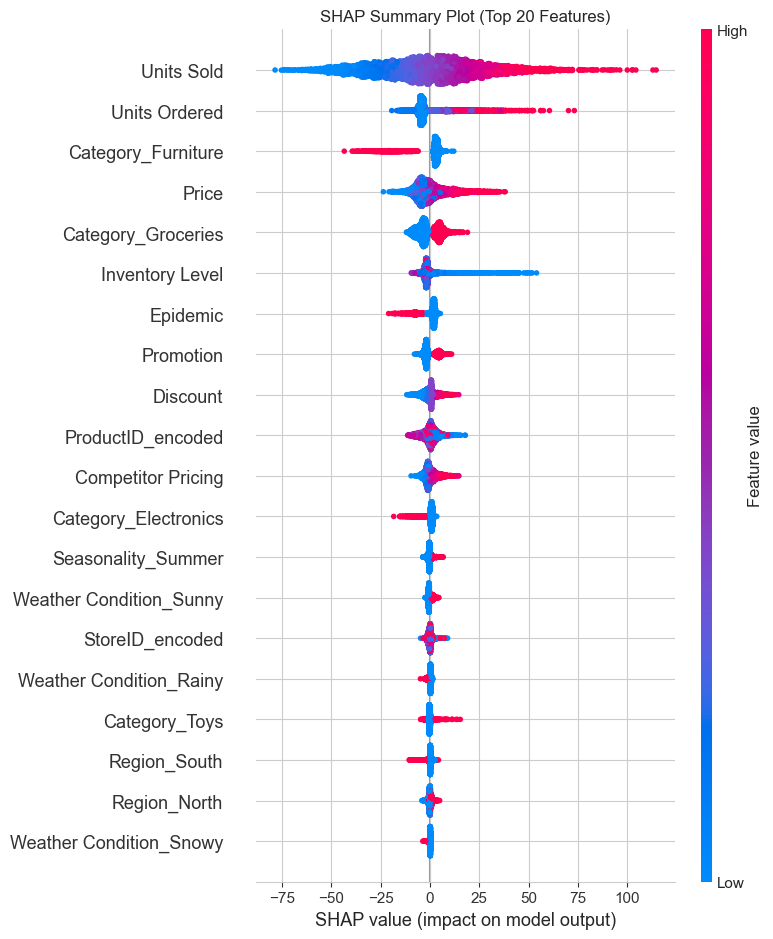

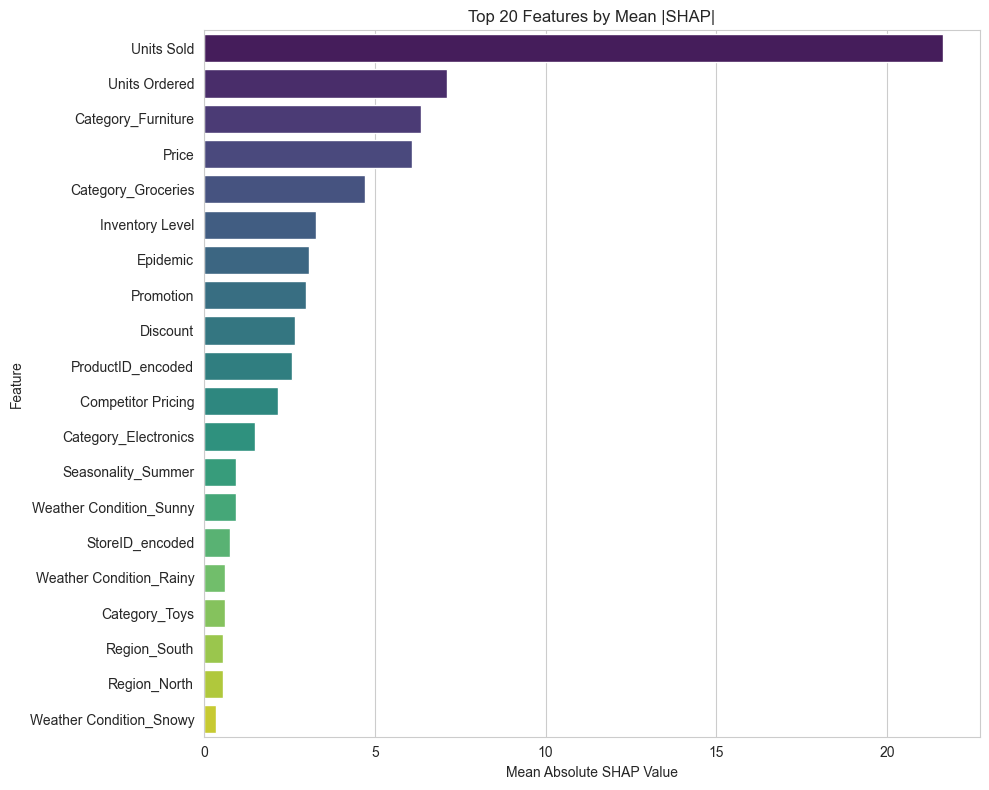


Top 15 influential features:
                    feature  mean_abs_shap
0                Units Sold      21.640510
1             Units Ordered       7.125831
2        Category_Furniture       6.361714
3                     Price       6.081680
4        Category_Groceries       4.707748
5           Inventory Level       3.278848
6                  Epidemic       3.061166
7                 Promotion       2.994445
8                  Discount       2.659535
9         ProductID_encoded       2.589936
10       Competitor Pricing       2.159306
11     Category_Electronics       1.503656
12       Seasonality_Summer       0.941381
13  Weather Condition_Sunny       0.928844
14          StoreID_encoded       0.751595

Step 12 complete. Artifacts saved:
  surrogate_features, surrogate_target, surrogate_feature_importance,
  surrogate_shap_sample, surrogate_shap_values


In [15]:
print("=" * 80)
print("STEP 12: FEATURE IMPORTANCE WITH LIGHTGBM + SHAP")
print("=" * 80)

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import OrdinalEncoder

# 1) Base preprocessed exogenous features from Step 6
surrogate_base = X_train_df.copy()

# 2) Add time features from train split
time_features = pd.DataFrame({
    'day_of_week': df_train_split['Date'].dt.dayofweek.values,
    'month': df_train_split['Date'].dt.month.values,
    'day_of_month': df_train_split['Date'].dt.day.values,
}, index=df_train_split.index)

# 3) Add encoded Store ID and Product ID for series-level effects
id_encoder = OrdinalEncoder()
id_encoded = id_encoder.fit_transform(df_train_split[['Store ID', 'Product ID']])
id_features = pd.DataFrame(
    id_encoded,
    columns=['StoreID_encoded', 'ProductID_encoded'],
    index=df_train_split.index,
 )

# 4) Build surrogate dataset
X_surrogate = pd.concat([
    surrogate_base.reset_index(drop=True),
    time_features.reset_index(drop=True),
    id_features.reset_index(drop=True),
], axis=1)
y_surrogate = df_train_split['Demand'].reset_index(drop=True)

print(f"Surrogate feature matrix shape: {X_surrogate.shape}")
print(f"Target shape: {y_surrogate.shape}")

# 5) Train/validation split for surrogate quality check
X_tr, X_val, y_tr, y_val = train_test_split(
    X_surrogate, y_surrogate, test_size=0.2, random_state=42
)

surrogate_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='regression',
    n_jobs=-1
)

surrogate_model.fit(X_tr, y_tr)
val_pred = surrogate_model.predict(X_val)

sur_mae = mean_absolute_error(y_val, val_pred)
sur_rmse = np.sqrt(mean_squared_error(y_val, val_pred))

print("\nSurrogate LightGBM validation metrics:")
print(f"  MAE: {sur_mae:.4f}")
print(f"  RMSE: {sur_rmse:.4f}")

# 6) SHAP analysis on sampled rows for speed
sample_n = min(5000, len(X_surrogate))
X_shap = X_surrogate.sample(n=sample_n, random_state=42)
print(f"\nComputing SHAP values on {len(X_shap)} rows...")

explainer = shap.TreeExplainer(surrogate_model)
shap_values = explainer.shap_values(X_shap)

# Beeswarm summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_shap, show=False, max_display=20)
plt.title('SHAP Summary Plot (Top 20 Features)')
plt.tight_layout()
plt.show()

# Bar plot of mean absolute SHAP importance
mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    'feature': X_shap.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

top_n = 20
plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(top_n), x='mean_abs_shap', y='feature', palette='viridis')
plt.title(f'Top {top_n} Features by Mean |SHAP|')
plt.xlabel('Mean Absolute SHAP Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nTop 15 influential features:")
print(importance_df.head(15))

# Save artifacts for reuse
surrogate_features = X_surrogate
surrogate_target = y_surrogate
surrogate_feature_importance = importance_df
surrogate_shap_sample = X_shap
surrogate_shap_values = shap_values

print("\nStep 12 complete. Artifacts saved:")
print("  surrogate_features, surrogate_target, surrogate_feature_importance,")
print("  surrogate_shap_sample, surrogate_shap_values")

# Step 13: Grouped Feature Importance (Category/Region consolidated)

STEP 13: GROUPED FEATURE IMPORTANCE
Grouped importance table:
         feature_group  mean_abs_shap
0           Units Sold      21.640510
1             Category      13.181629
2        Units Ordered       7.125831
3                Price       6.081680
4      Inventory Level       3.278848
5             Epidemic       3.061166
6            Promotion       2.994445
7             Discount       2.659535
8           Product ID       2.589936
9   Competitor Pricing       2.159306
10   Weather Condition       1.914187
11              Region       1.391090
12         Seasonality       1.148301
13            Store ID       0.751595
14            Calendar       0.415087


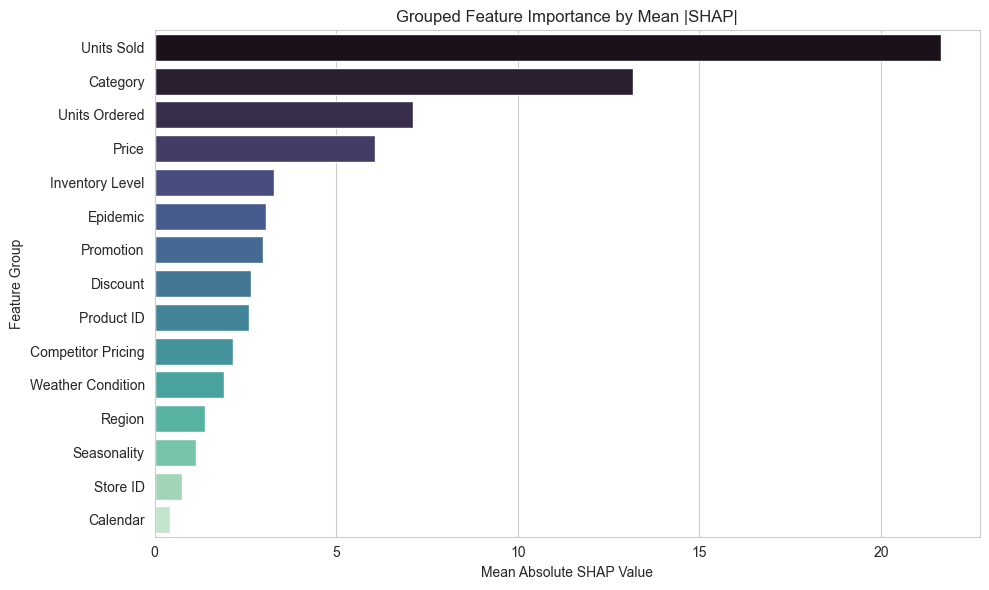


Requested grouped features:
   feature_group  mean_abs_shap
1       Category      13.181629
11        Region       1.391090


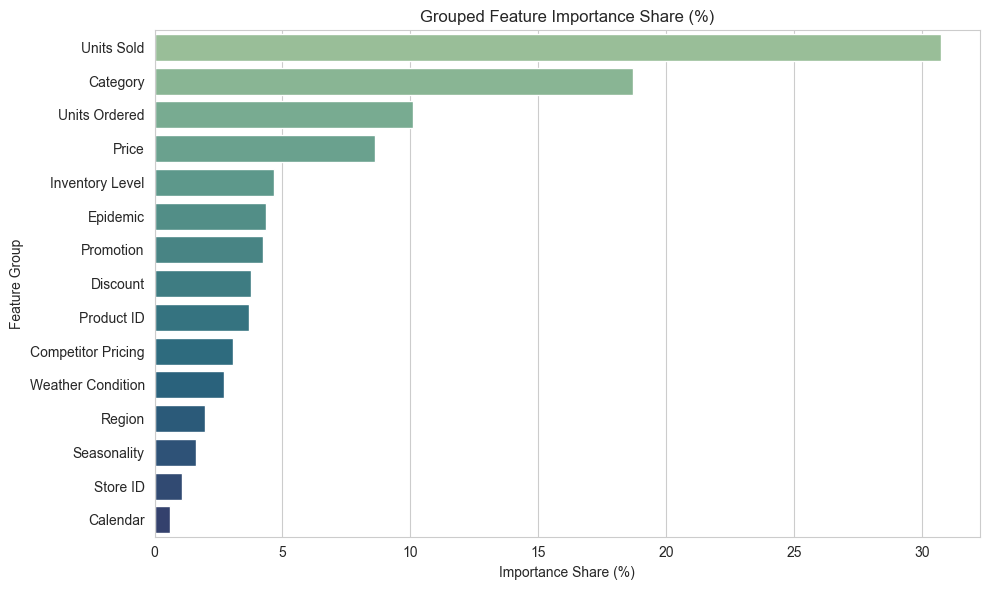


Step 13 complete. Artifact saved: grouped_feature_importance


In [16]:
print("=" * 80)
print("STEP 13: GROUPED FEATURE IMPORTANCE")
print("=" * 80)

# Use row-wise absolute SHAP values from Step 12
shap_abs_df = pd.DataFrame(
    np.abs(surrogate_shap_values),
    columns=surrogate_shap_sample.columns,
    index=surrogate_shap_sample.index,
)

# Map expanded columns to grouped feature families
feature_group_map = {
    'Category_': 'Category',
    'Region_': 'Region',
    'Weather Condition_': 'Weather Condition',
    'Seasonality_': 'Seasonality',
    'StoreID_encoded': 'Store ID',
    'ProductID_encoded': 'Product ID',
    'day_of_week': 'Calendar',
    'day_of_month': 'Calendar',
    'month': 'Calendar',
    'Price': 'Price',
    'Discount': 'Discount',
    'Inventory Level': 'Inventory Level',
    'Units Sold': 'Units Sold',
    'Units Ordered': 'Units Ordered',
    'Competitor Pricing': 'Competitor Pricing',
    'Promotion': 'Promotion',
    'Epidemic': 'Epidemic',
}

def map_feature_to_group(col_name: str) -> str:
    for prefix, group_name in feature_group_map.items():
        if col_name.startswith(prefix):
            return group_name
    return 'Other'

column_groups = pd.Series(shap_abs_df.columns).apply(map_feature_to_group).values

# Aggregate each row's absolute SHAP by group, then average across rows
grouped_abs_shap = shap_abs_df.T.groupby(column_groups).sum().T
group_importance = grouped_abs_shap.mean(axis=0).sort_values(ascending=False).reset_index()
group_importance.columns = ['feature_group', 'mean_abs_shap']

print("Grouped importance table:")
print(group_importance)

# Plot grouped feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=group_importance, x='mean_abs_shap', y='feature_group', palette='mako')
plt.title('Grouped Feature Importance by Mean |SHAP|')
plt.xlabel('Mean Absolute SHAP Value')
plt.ylabel('Feature Group')
plt.tight_layout()
plt.show()

# Highlight requested groups explicitly
requested_groups = ['Category', 'Region']
requested_view = group_importance[group_importance['feature_group'].isin(requested_groups)].copy()
print("\nRequested grouped features:")
print(requested_view)

# Optional normalized share (%)
group_importance['importance_pct'] = (
    group_importance['mean_abs_shap'] / group_importance['mean_abs_shap'].sum() * 100
)

plt.figure(figsize=(10, 6))
sns.barplot(data=group_importance, x='importance_pct', y='feature_group', palette='crest')
plt.title('Grouped Feature Importance Share (%)')
plt.xlabel('Importance Share (%)')
plt.ylabel('Feature Group')
plt.tight_layout()
plt.show()

# Save for downstream use
grouped_feature_importance = group_importance
print("\nStep 13 complete. Artifact saved: grouped_feature_importance")

# Step 14: Business-Friendly SHAP Interpretation (Demand Impact in Units)

STEP 14: BUSINESS-FRIENDLY SHAP INTERPRETATION

Top grouped demand drivers (business view):
         Feature Group  Avg Absolute Impact (Demand Units)  \
0           Units Sold                           21.640510   
1             Category                           13.181629   
2        Units Ordered                            7.125831   
3                Price                            6.081680   
4      Inventory Level                            3.278848   
5             Epidemic                            3.061166   
6            Promotion                            2.994445   
7             Discount                            2.659535   
8           Product ID                            2.589936   
9   Competitor Pricing                            2.159306   
10   Weather Condition                            1.914187   
11              Region                            1.391090   

    Median Absolute Impact (Demand Units)  Avg Net Impact (Demand Units)  \
0                        

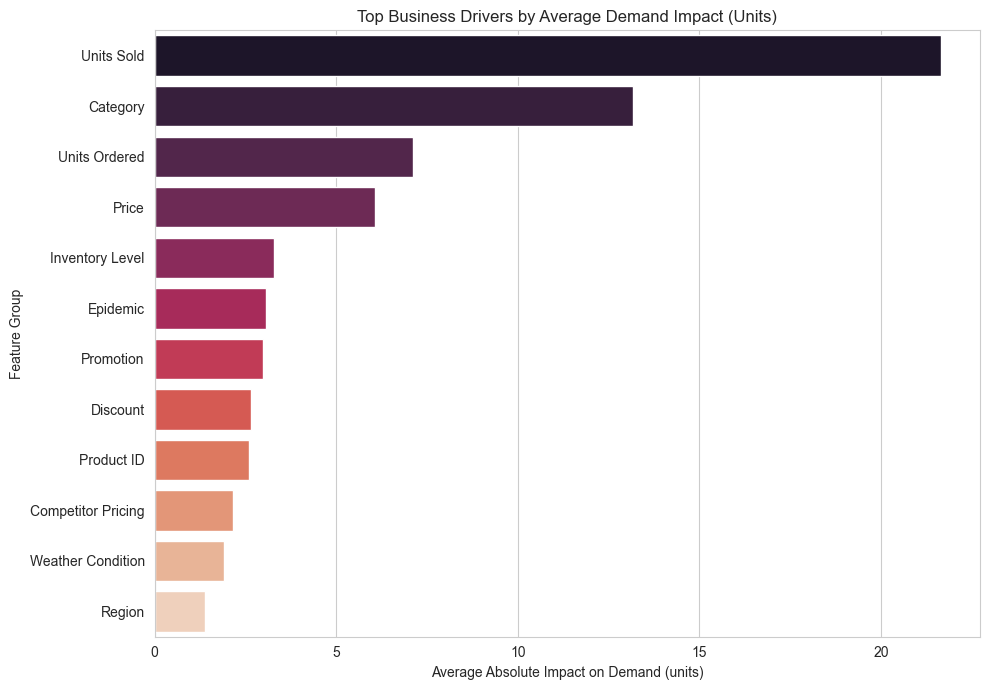

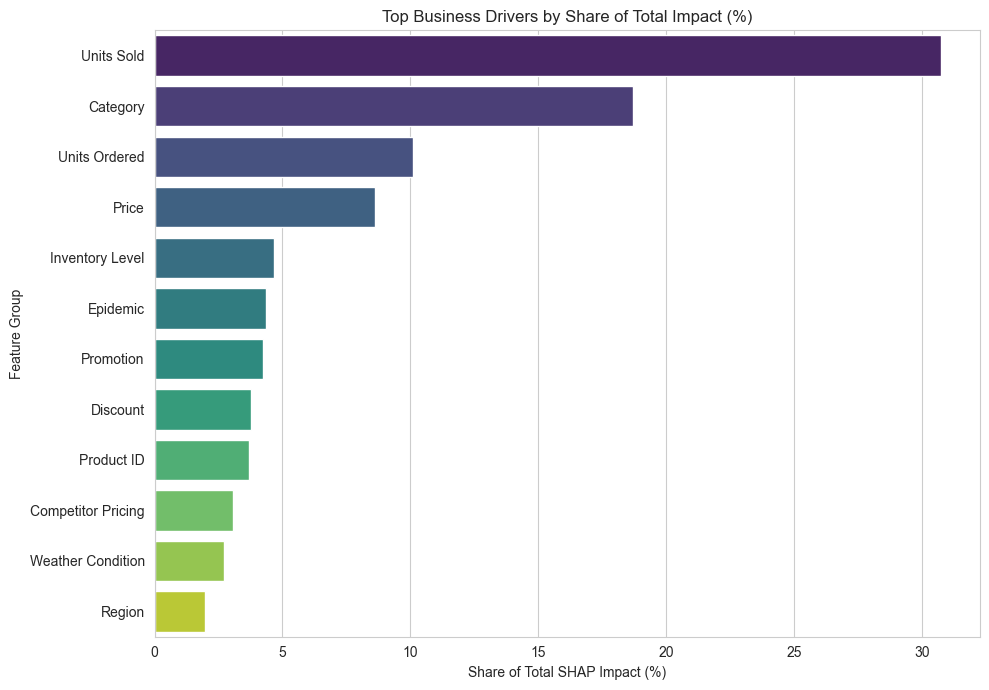


Category impact on Demand (grouped as one feature):
      Category  Avg_Impact_Units  Median_Impact_Units  Avg_Abs_Impact_Units
2    Furniture        -26.245624           -26.637897             26.245624
3    Groceries          8.668152             8.247121              8.668152
1  Electronics         -6.866561            -6.433327              6.882191
4         Toys          2.790563             2.898210              3.275301
0     Clothing          1.322536             1.172326              2.398745

Region impact on Demand (grouped as one feature):
  Region  Avg_Impact_Units  Median_Impact_Units  Avg_Abs_Impact_Units
2  South         -1.791516            -1.254089              1.884095
1  North          0.695194             0.630183              0.894945
3   West          0.531022             0.317189              0.805330
0   East         -0.196218            -0.086304              0.696700


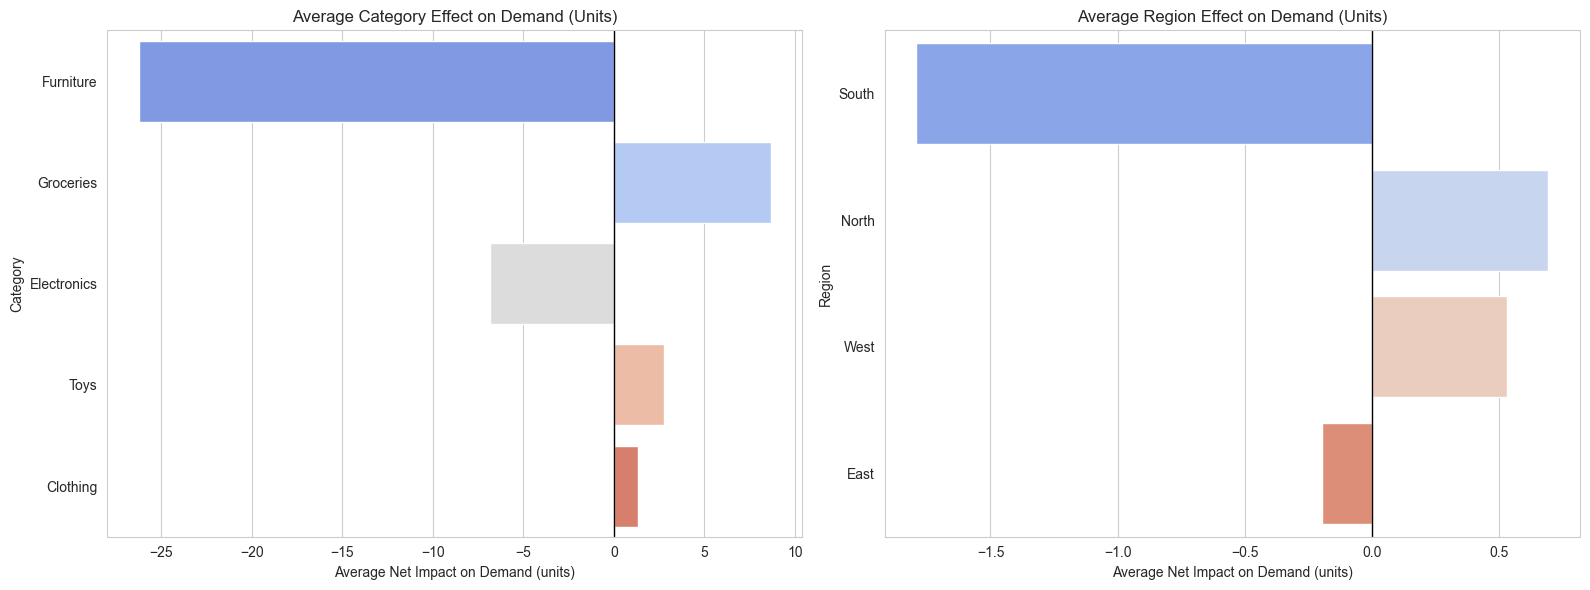

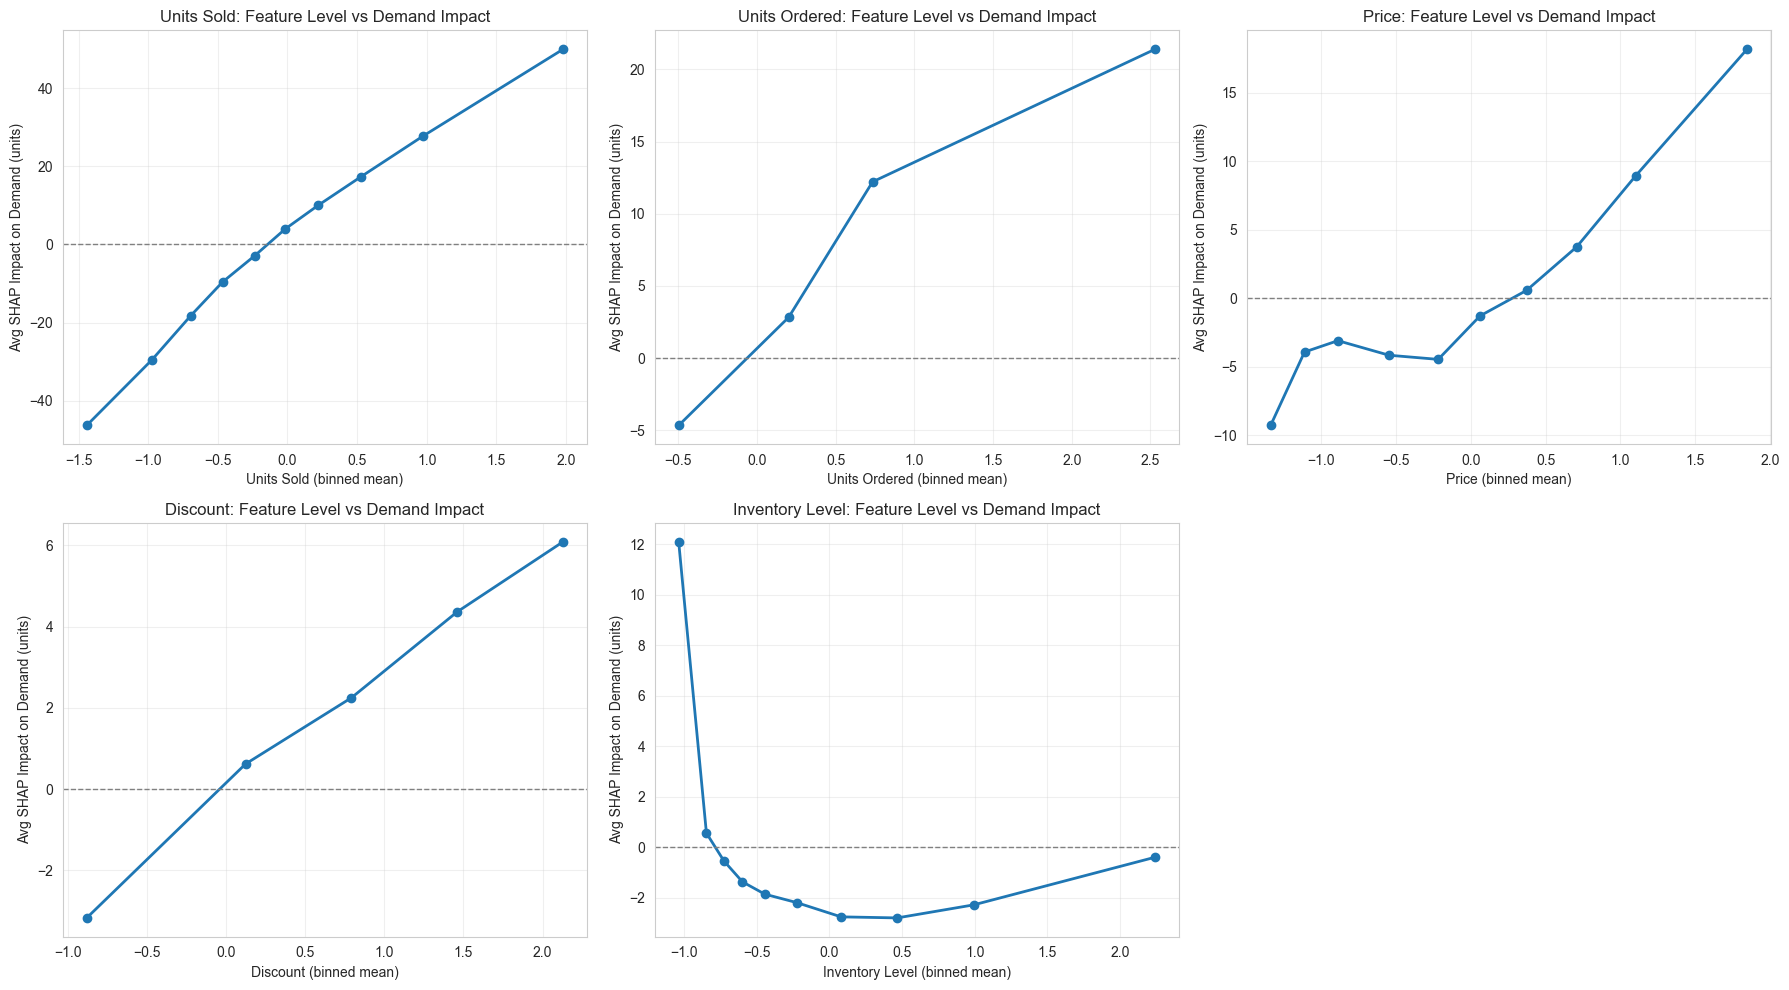


Step 14 complete. Business-facing artifacts saved:
  business_driver_impact, category_business_impact, region_business_impact


In [18]:
print("=" * 80)
print("STEP 14: BUSINESS-FRIENDLY SHAP INTERPRETATION")
print("=" * 80)

# SHAP values for regression are already in target units (Demand units)
shap_signed_df = pd.DataFrame(
    surrogate_shap_values,
    columns=surrogate_shap_sample.columns,
    index=surrogate_shap_sample.index,
)
shap_abs_df = shap_signed_df.abs()

# -----------------------------
# 14A) Grouped driver impact in Demand units
# -----------------------------
feature_group_map = {
    'Category_': 'Category',
    'Region_': 'Region',
    'Weather Condition_': 'Weather Condition',
    'Seasonality_': 'Seasonality',
    'StoreID_encoded': 'Store ID',
    'ProductID_encoded': 'Product ID',
    'day_of_week': 'Calendar',
    'day_of_month': 'Calendar',
    'month': 'Calendar',
    'Price': 'Price',
    'Discount': 'Discount',
    'Inventory Level': 'Inventory Level',
    'Units Sold': 'Units Sold',
    'Units Ordered': 'Units Ordered',
    'Competitor Pricing': 'Competitor Pricing',
    'Promotion': 'Promotion',
    'Epidemic': 'Epidemic',
}

def map_feature_to_group(col_name: str) -> str:
    for prefix, group_name in feature_group_map.items():
        if col_name.startswith(prefix):
            return group_name
    return 'Other'

feature_to_group = pd.Series(shap_signed_df.columns, index=shap_signed_df.columns).apply(map_feature_to_group)

# Sum feature contributions into groups per row
grouped_signed = shap_signed_df.T.groupby(feature_to_group).sum().T
grouped_abs = shap_abs_df.T.groupby(feature_to_group).sum().T

grouped_driver_table = pd.DataFrame({
    'Feature Group': grouped_abs.columns,
    'Avg Absolute Impact (Demand Units)': grouped_abs.mean(axis=0).values,
    'Median Absolute Impact (Demand Units)': grouped_abs.median(axis=0).values,
    'Avg Net Impact (Demand Units)': grouped_signed.mean(axis=0).values,
})
grouped_driver_table = grouped_driver_table.sort_values(
    'Avg Absolute Impact (Demand Units)', ascending=False
).reset_index(drop=True)

total_abs = grouped_driver_table['Avg Absolute Impact (Demand Units)'].sum()
grouped_driver_table['Share of Total Impact (%)'] = (
    grouped_driver_table['Avg Absolute Impact (Demand Units)'] / total_abs * 100
)

print("\nTop grouped demand drivers (business view):")
print(grouped_driver_table.head(12))

plt.figure(figsize=(10, 7))
sns.barplot(
    data=grouped_driver_table.head(12),
    x='Avg Absolute Impact (Demand Units)',
    y='Feature Group',
    palette='rocket'
)
plt.title('Top Business Drivers by Average Demand Impact (Units)')
plt.xlabel('Average Absolute Impact on Demand (units)')
plt.ylabel('Feature Group')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 7))
sns.barplot(
    data=grouped_driver_table.head(12),
    x='Share of Total Impact (%)',
    y='Feature Group',
    palette='viridis'
)
plt.title('Top Business Drivers by Share of Total Impact (%)')
plt.xlabel('Share of Total SHAP Impact (%)')
plt.ylabel('Feature Group')
plt.tight_layout()
plt.show()

# -----------------------------
# 14B) Category and Region impact as single business features
# -----------------------------
# Align metadata to SHAP sample using positional index from reset DataFrame
meta_source = df_train_split[['Category', 'Region']].reset_index(drop=True)
meta_sample = meta_source.loc[surrogate_shap_sample.index].copy()

category_cols = [c for c in shap_signed_df.columns if c.startswith('Category_')]
region_cols = [c for c in shap_signed_df.columns if c.startswith('Region_')]

if category_cols:
    category_row_impact = shap_signed_df[category_cols].sum(axis=1)
else:
    category_row_impact = pd.Series(0.0, index=shap_signed_df.index)

if region_cols:
    region_row_impact = shap_signed_df[region_cols].sum(axis=1)
else:
    region_row_impact = pd.Series(0.0, index=shap_signed_df.index)

category_impact_table = (
    pd.DataFrame({'Category': meta_sample['Category'].values, 'Impact': category_row_impact.values})
    .groupby('Category', as_index=False)
    .agg(
        Avg_Impact_Units=('Impact', 'mean'),
        Median_Impact_Units=('Impact', 'median'),
        Avg_Abs_Impact_Units=('Impact', lambda x: np.mean(np.abs(x)))
    )
    .sort_values('Avg_Abs_Impact_Units', ascending=False)
)

region_impact_table = (
    pd.DataFrame({'Region': meta_sample['Region'].values, 'Impact': region_row_impact.values})
    .groupby('Region', as_index=False)
    .agg(
        Avg_Impact_Units=('Impact', 'mean'),
        Median_Impact_Units=('Impact', 'median'),
        Avg_Abs_Impact_Units=('Impact', lambda x: np.mean(np.abs(x)))
    )
    .sort_values('Avg_Abs_Impact_Units', ascending=False)
)

print("\nCategory impact on Demand (grouped as one feature):")
print(category_impact_table)

print("\nRegion impact on Demand (grouped as one feature):")
print(region_impact_table)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=category_impact_table, x='Avg_Impact_Units', y='Category', palette='coolwarm', ax=axes[0])
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('Average Category Effect on Demand (Units)')
axes[0].set_xlabel('Average Net Impact on Demand (units)')
axes[0].set_ylabel('Category')

sns.barplot(data=region_impact_table, x='Avg_Impact_Units', y='Region', palette='coolwarm', ax=axes[1])
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Average Region Effect on Demand (Units)')
axes[1].set_xlabel('Average Net Impact on Demand (units)')
axes[1].set_ylabel('Region')

plt.tight_layout()
plt.show()

# -----------------------------
# 14C) How feature movement changes demand (simple, business-friendly curves)
# -----------------------------
key_numeric = ['Units Sold', 'Units Ordered', 'Price', 'Discount', 'Inventory Level']
available_numeric = [c for c in key_numeric if c in surrogate_shap_sample.columns]

impact_curve_data = []
for col in available_numeric:
    tmp = pd.DataFrame({
        'feature_value': surrogate_shap_sample[col].values,
        'shap_impact': shap_signed_df[col].values
    }).dropna()

    # 10 quantile bins for an easy business curve
    tmp['bin'] = pd.qcut(tmp['feature_value'], q=10, duplicates='drop')
    agg = tmp.groupby('bin').agg(
        feature_value_mean=('feature_value', 'mean'),
        demand_impact_mean=('shap_impact', 'mean')
    ).reset_index(drop=True)
    agg['feature'] = col
    impact_curve_data.append(agg)

if impact_curve_data:
    impact_curve_df = pd.concat(impact_curve_data, ignore_index=True)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()

    for i, col in enumerate(available_numeric):
        ax = axes[i]
        part = impact_curve_df[impact_curve_df['feature'] == col]
        ax.plot(part['feature_value_mean'], part['demand_impact_mean'], marker='o', linewidth=2)
        ax.axhline(0, color='gray', linestyle='--', linewidth=1)
        ax.set_title(f'{col}: Feature Level vs Demand Impact')
        ax.set_xlabel(f'{col} (binned mean)')
        ax.set_ylabel('Avg SHAP Impact on Demand (units)')
        ax.grid(alpha=0.3)

    for j in range(len(available_numeric), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Save business-facing artifacts
business_driver_impact = grouped_driver_table
category_business_impact = category_impact_table
region_business_impact = region_impact_table

print("\nStep 14 complete. Business-facing artifacts saved:")
print("  business_driver_impact, category_business_impact, region_business_impact")

# Step 15: Category-Wise GBM + SHAP (independent category models)

STEP 15: CATEGORY-WISE GBM + SHAP
Categories found: ['Clothing', 'Electronics', 'Furniture', 'Groceries', 'Toys']
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001362 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1342
[LightGBM] [Info] Number of data points in the train set: 9548, number of used features: 22
[LightGBM] [Info] Start training from score 112.409929
Done: Clothing | rows=11936 | RMSE=9.901
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000732 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1325
[LightGBM] [Info] Number of data points in the train set: 7161, number of used features: 22
[LightGBM] [Info] Start training from score 97.327748


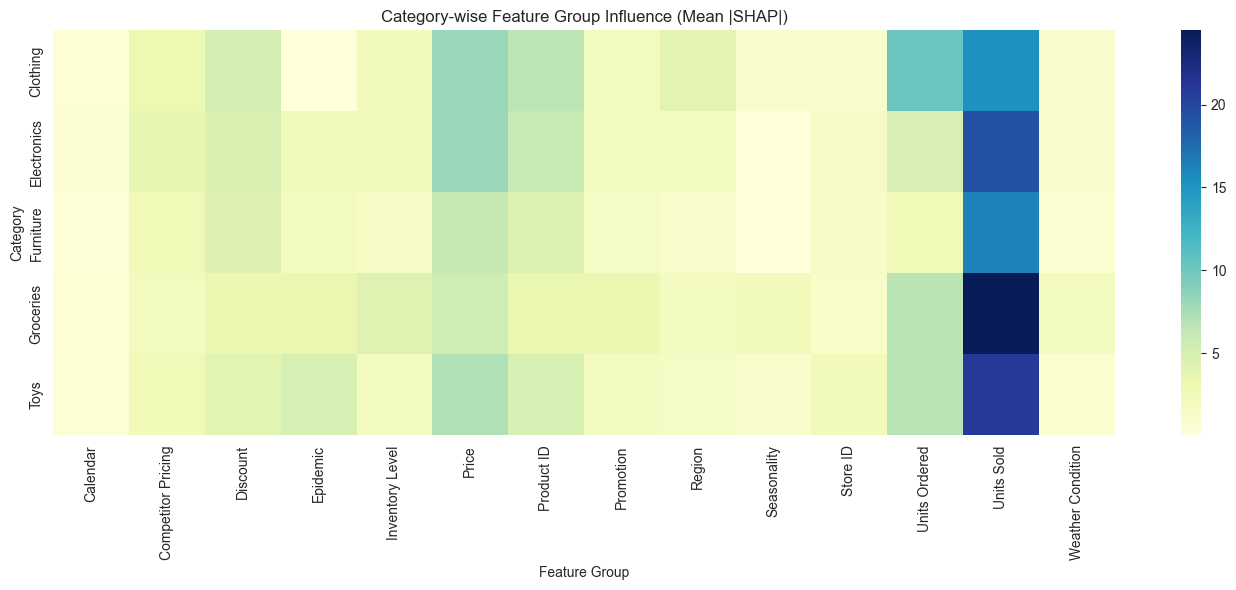

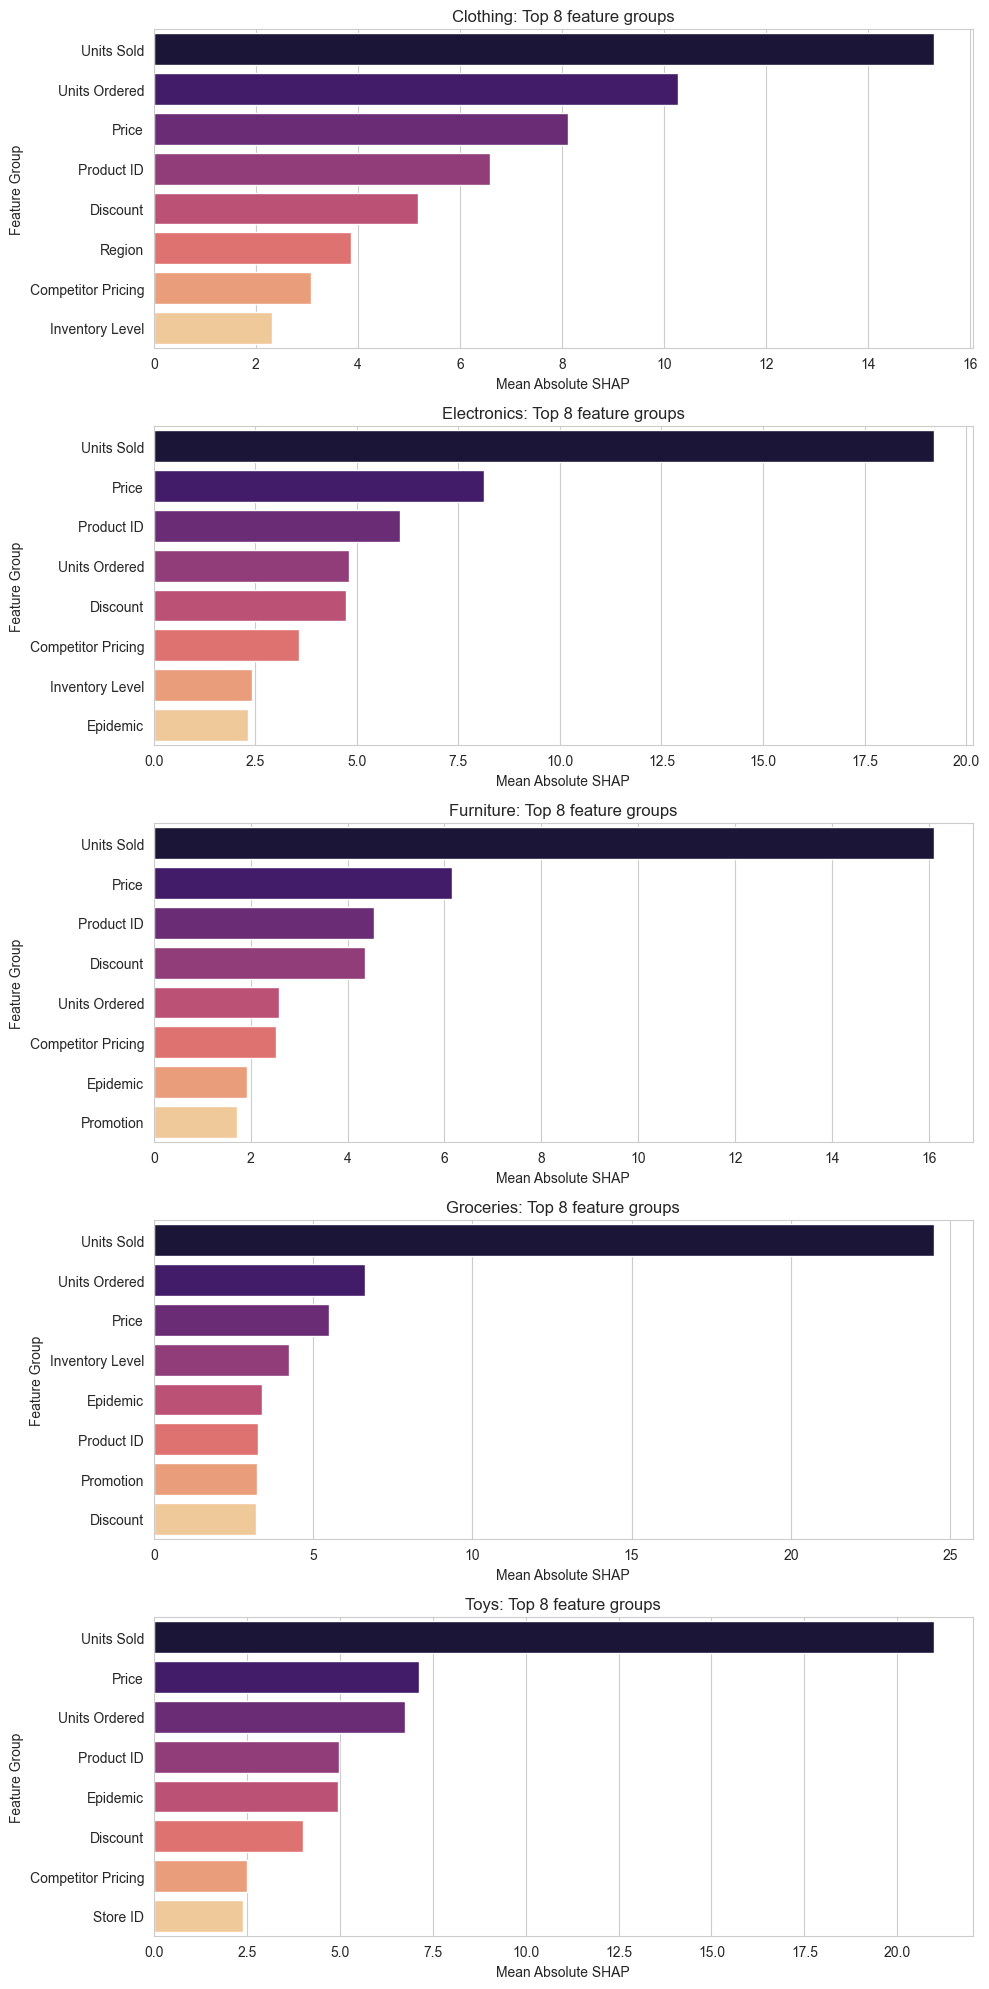


Artifacts saved:
  category_model_quality
  category_feature_group_impact
  category_top_features
  category_models


In [19]:
print("=" * 80)
print("STEP 15: CATEGORY-WISE GBM + SHAP")
print("=" * 80)

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

category_values = sorted(df_train_split['Category'].dropna().unique().tolist())
print(f"Categories found: {category_values}")

category_model_rows = []
category_group_rows = []
category_top_feature_rows = []
category_models = {}

for category_name in category_values:
    cat_df = df_train_split[df_train_split['Category'] == category_name].copy().reset_index(drop=True)
    
    if len(cat_df) < 200:
        print(f"Skipping {category_name}: not enough rows ({len(cat_df)})")
        continue

    # Build category-specific design matrix without Category as an input feature
    local_numeric = numeric_features.copy()
    local_categorical = ['Region', 'Weather Condition', 'Seasonality']
    local_binary = binary_features.copy()

    local_preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), local_numeric),
            ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), local_categorical),
            ('bin', 'passthrough', local_binary),
        ],
        remainder='drop',
    )

    X_local_processed = local_preprocessor.fit_transform(
        cat_df[local_numeric + local_categorical + local_binary]
    )

    local_cat_feature_names = list(
        local_preprocessor.named_transformers_['cat'].get_feature_names_out(local_categorical)
    )
    local_feature_names = local_numeric + local_cat_feature_names + local_binary

    X_local_df = pd.DataFrame(X_local_processed, columns=local_feature_names)

    local_time = pd.DataFrame({
        'day_of_week': cat_df['Date'].dt.dayofweek.values,
        'month': cat_df['Date'].dt.month.values,
        'day_of_month': cat_df['Date'].dt.day.values,
    })

    local_encoder = OrdinalEncoder()
    local_id_encoded = local_encoder.fit_transform(cat_df[['Store ID', 'Product ID']])
    local_id_df = pd.DataFrame(local_id_encoded, columns=['StoreID_encoded', 'ProductID_encoded'])

    X_cat = pd.concat([X_local_df, local_time, local_id_df], axis=1)
    y_cat = cat_df['Demand'].astype(float).reset_index(drop=True)

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_cat, y_cat, test_size=0.2, random_state=42
    )

    model_cat = lgb.LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective='regression',
        n_jobs=-1,
    )

    model_cat.fit(X_tr, y_tr)
    pred_val = model_cat.predict(X_val)

    cat_mae = mean_absolute_error(y_val, pred_val)
    cat_rmse = np.sqrt(mean_squared_error(y_val, pred_val))

    category_model_rows.append({
        'Category': category_name,
        'Rows': len(cat_df),
        'MAE': cat_mae,
        'RMSE': cat_rmse,
    })

    # SHAP within category
    sample_n_local = min(2000, len(X_cat))
    X_cat_shap = X_cat.sample(n=sample_n_local, random_state=42)
    shap_cat_values = shap.TreeExplainer(model_cat).shap_values(X_cat_shap)

    shap_cat_abs = pd.DataFrame(
        np.abs(shap_cat_values),
        columns=X_cat_shap.columns,
        index=X_cat_shap.index,
    )

    # Top features for this category
    top_feat = (
        shap_cat_abs.mean(axis=0)
        .sort_values(ascending=False)
        .reset_index()
    )
    top_feat.columns = ['Feature', 'MeanAbsSHAP']
    top_feat['Category'] = category_name
    category_top_feature_rows.append(top_feat.head(15))

    # Grouped SHAP impacts for easier cross-category comparison
    local_group_map = {
        'Region_': 'Region',
        'Weather Condition_': 'Weather Condition',
        'Seasonality_': 'Seasonality',
        'StoreID_encoded': 'Store ID',
        'ProductID_encoded': 'Product ID',
        'day_of_week': 'Calendar',
        'day_of_month': 'Calendar',
        'month': 'Calendar',
        'Price': 'Price',
        'Discount': 'Discount',
        'Inventory Level': 'Inventory Level',
        'Units Sold': 'Units Sold',
        'Units Ordered': 'Units Ordered',
        'Competitor Pricing': 'Competitor Pricing',
        'Promotion': 'Promotion',
        'Epidemic': 'Epidemic',
    }

    def map_local_group(col_name: str) -> str:
        for prefix, group_name in local_group_map.items():
            if col_name.startswith(prefix):
                return group_name
        return 'Other'

    local_groups = pd.Series(shap_cat_abs.columns).apply(map_local_group).values
    grouped_local = shap_cat_abs.T.groupby(local_groups).sum().T

    grouped_table = (
        grouped_local.mean(axis=0)
        .sort_values(ascending=False)
        .reset_index()
    )
    grouped_table.columns = ['Feature Group', 'MeanAbsSHAP']
    grouped_table['Category'] = category_name
    category_group_rows.append(grouped_table)

    category_models[category_name] = model_cat
    print(f"Done: {category_name} | rows={len(cat_df)} | RMSE={cat_rmse:.3f}")

category_model_quality = pd.DataFrame(category_model_rows).sort_values('RMSE').reset_index(drop=True)
category_feature_group_impact = pd.concat(category_group_rows, ignore_index=True) if category_group_rows else pd.DataFrame()
category_top_features = pd.concat(category_top_feature_rows, ignore_index=True) if category_top_feature_rows else pd.DataFrame()

print("\nCategory-wise model quality:")
print(category_model_quality)

if not category_feature_group_impact.empty:
    # Heatmap: category vs feature-group influence
    heatmap_df = category_feature_group_impact.pivot(
        index='Category', columns='Feature Group', values='MeanAbsSHAP'
    ).fillna(0.0)

    plt.figure(figsize=(14, 6))
    sns.heatmap(heatmap_df, cmap='YlGnBu', annot=False)
    plt.title('Category-wise Feature Group Influence (Mean |SHAP|)')
    plt.xlabel('Feature Group')
    plt.ylabel('Category')
    plt.tight_layout()
    plt.show()

    # Top groups per category (small multiples)
    cats_for_plot = category_feature_group_impact['Category'].unique().tolist()
    fig, axes = plt.subplots(len(cats_for_plot), 1, figsize=(10, 4 * len(cats_for_plot)))
    if len(cats_for_plot) == 1:
        axes = [axes]

    for ax, category_name in zip(axes, cats_for_plot):
        part = (
            category_feature_group_impact[category_feature_group_impact['Category'] == category_name]
            .sort_values('MeanAbsSHAP', ascending=False)
            .head(8)
        )
        sns.barplot(data=part, x='MeanAbsSHAP', y='Feature Group', ax=ax, palette='magma')
        ax.set_title(f"{category_name}: Top 8 feature groups")
        ax.set_xlabel('Mean Absolute SHAP')
        ax.set_ylabel('Feature Group')

    plt.tight_layout()
    plt.show()

print("\nArtifacts saved:")
print("  category_model_quality")
print("  category_feature_group_impact")
print("  category_top_features")
print("  category_models")